<div class="alert alert-block">
<b>Step 3:</b> Models</div>

_Imports_

In [11]:
import pandas as pd
import geopandas as gpd # (.shp)
import matplotlib.pyplot as plt
import rasterio # (.tif)
from rasterio.mask import mask
from tqdm import tqdm
import os
import glob
import seaborn as sns
import numpy as np
#import pyodbc
from rasterstats import zonal_stats
import pickle
from shapely.geometry import Point
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from collections import Counter
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, accuracy_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix





_Loading Datasets_

In [13]:
"""
save_path = "data/processed/df_2km.pkl"

with open(save_path, "rb") as f:
       df_2km = pickle.load(f)       

save_path = "data/processed/df_encoded.pkl" 
save_path = "/content/drive/MyDrive/project/df_encoded.pkl" 
"""

save_path = "data/processed/df_encoded.pkl"

with open(save_path, "rb") as f:
  df_encoded = pickle.load(f)

# Chemins vers les fichiers pickle
X_train_path = "data/processed/X_train.pkl"
y_train_path = "data/processed/y_train.pkl"
X_test_path  = "data/processed/X_test.pkl"
y_test_path  = "data/processed/y_test.pkl"

# Chargement des fichiers pickle
with open(X_train_path, "rb") as f:
    X_train = pickle.load(f)

with open(y_train_path, "rb") as f:
    y_train = pickle.load(f)

with open(X_test_path, "rb") as f:
    X_test = pickle.load(f)

with open(y_test_path, "rb") as f:
    y_test = pickle.load(f)


X_train_res_smote_path = "data/processed/X_train_res_smote.pkl"
y_train_res_smote_path = "data/processed/y_train_res_smote.pkl"
X_train_res_rus_path = "data/processed/X_train_res_rus.pkl"
y_train_res_rus_path = "data/processed/y_train_res_rus.pkl"

with open(X_train_res_smote_path, "rb") as f:
    X_train_res_smote = pickle.load(f)

with open(y_train_res_smote_path, "rb") as f:
    y_train_res_smote = pickle.load(f)

with open(X_train_res_rus_path, "rb") as f:
    X_train_res_rus = pickle.load(f)

with open(y_train_res_rus_path, "rb") as f:
    y_train_res_rus = pickle.load(f)

with open("data/processed/y_pred_knn_smote.pkl", "rb") as f:
    y_pred_knn_smote = pickle.load(f)

with open("data/processed/y_pred_knn_rus.pkl", "rb") as f:
    y_pred_knn_rus = pickle.load(f)

with open("data/processed/y_pred_dt_smote.pkl", "rb") as f:
    y_pred_dt_smote = pickle.load(f)

with open("data/processed/y_pred_dt_rus.pkl", "rb") as f:
    y_pred_dt_rus = pickle.load(f)

with open("data/processed/y_pred_rf_original.pkl", "rb") as f:
    y_pred_rf_orig = pickle.load(f)

with open("data/processed/y_pred_rf_smote.pkl", "rb") as f:
    y_pred_rf_smote = pickle.load(f)

with open("data/processed/y_pred_rf_balanced.pkl", "rb") as f:
    y_pred_rf_balanced = pickle.load(f)

y_pred_dbscan_path = "data/processed/y_pred_dbscan.pkl"

with open(y_pred_dbscan_path, "rb") as f:
    y_pred_dbscan = pickle.load(f) 

cleaned_path = "data/processed/df_cleaned.pkl"

with open(cleaned_path, "rb") as f:
    df_cleaned = pickle.load(f)
 
save_path = "data/processed/df_encoded.pkl"
 

all_path = "data/processed/df_all.pkl"

with open(all_path, "rb") as f:
    df_all = pickle.load(f) 

"""
encoded = cleaned (we changed the name because the original code was written with df_encoded so we did it for convenience)
df_encoded = df_cleaned.copy() 
 """



'\nencoded = cleaned (we changed the name because the original code was written with df_encoded so we did it for convenience)\ndf_encoded = df_cleaned.copy() \n '

In [ ]:
df_encoded.columns


Index(['prec_winter', 'prec_spring', 'prec_summer', 'prec_fall', 'tmax_winter',
       'tmax_spring', 'tmax_summer', 'tmax_fall', 'tmin_winter', 'tmin_spring',
       'tmin_summer', 'tmin_fall', 'elevation', 'COARSE', 'SAND', 'CLAY',
       'ORG_CARBON', 'PH_WATER', 'CN_RATIO', 'CEC_CLAY', 'CEC_EFF', 'BSAT',
       'ALUM_SAT', 'TCARBON_EQ', 'GYPSUM', 'TEXTURE_SOTER_-',
       'TEXTURE_SOTER_C', 'TEXTURE_SOTER_F', 'TEXTURE_SOTER_M',
       'ELEC_COND_0.0', 'ELEC_COND_1.0', 'ELEC_COND_14.0', 'ELEC_COND_16.0',
       'ELEC_COND_2.0', 'ELEC_COND_32.0', 'LCCCode_0003 / 0004',
       'LCCCode_0004 // 0003', 'LCCCode_0010', 'LCCCode_0011',
       'LCCCode_11490 // 11494', 'LCCCode_11498', 'LCCCode_20049 // 20058',
       'LCCCode_20058', 'LCCCode_21446 // 21450-121340 / 21454',
       'LCCCode_21450', 'LCCCode_21454 // 21446 // 21450',
       'LCCCode_21496-121340 // 21497-129401', 'LCCCode_21497-121340',
       'LCCCode_21497-15045', 'LCCCode_21499-121340', 'LCCCode_21518',
       'LCCCode_6

In [ ]:
# Convert boolean columns to integers
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

# Verify
print(df_encoded[bool_cols].head())
print(df_encoded.dtypes)


Empty DataFrame
Columns: []
Index: [0, 1, 2, 3, 4]
prec_winter                              float32
prec_spring                              float32
prec_summer                              float32
prec_fall                                float32
tmax_winter                              float32
tmax_spring                              float32
tmax_summer                              float32
tmax_fall                                float32
tmin_winter                              float32
tmin_spring                              float32
tmin_summer                              float32
tmin_fall                                float32
elevation                                  int16
COARSE                                   float64
SAND                                     float64
CLAY                                     float64
ORG_CARBON                               float64
PH_WATER                                 float64
CN_RATIO                                 float64
CEC_CLAY          

In [ ]:
# Make sure all columns are displayed
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)  # widen display
pd.set_option('display.max_rows', None)  # optional, for rows

# Now print the dtypes
print(df_encoded.dtypes)



lat                                      float64
lon                                      float64
fire                                       int64
prec_winter                              float32
prec_spring                              float32
prec_summer                              float32
prec_fall                                float32
tmax_winter                              float32
tmax_spring                              float32
tmax_summer                              float32
tmax_fall                                float32
tmin_winter                              float32
tmin_spring                              float32
tmin_summer                              float32
tmin_fall                                float32
elevation                                  int16
COARSE                                   float64
SAND                                     float64
CLAY                                     float64
ORG_CARBON                               float64
PH_WATER            

In [ ]:
# Fill NaNs with 0 (or any suitable value)
df_encoded = df_encoded.fillna(0)


## Split Train/Test

In [ ]:
df_all.columns

Index(['lat', 'lon', 'fire', 'prec_winter', 'prec_spring', 'prec_summer',
       'prec_fall', 'tmax_winter', 'tmax_spring', 'tmax_summer', 'tmax_fall',
       'tmin_winter', 'tmin_spring', 'tmin_summer', 'tmin_fall', 'elevation',
       'COARSE', 'SAND', 'CLAY', 'ORG_CARBON', 'PH_WATER', 'CN_RATIO',
       'CEC_CLAY', 'CEC_EFF', 'BSAT', 'ALUM_SAT', 'TCARBON_EQ', 'GYPSUM',
       'TEXTURE_SOTER_-', 'TEXTURE_SOTER_C', 'TEXTURE_SOTER_F',
       'TEXTURE_SOTER_M', 'ELEC_COND_0.0', 'ELEC_COND_1.0', 'ELEC_COND_14.0',
       'ELEC_COND_16.0', 'ELEC_COND_2.0', 'ELEC_COND_32.0',
       'LCCCode_0003 / 0004', 'LCCCode_0004 // 0003', 'LCCCode_0010',
       'LCCCode_0011', 'LCCCode_11490 // 11494', 'LCCCode_11498',
       'LCCCode_20049 // 20058', 'LCCCode_20058',
       'LCCCode_21446 // 21450-121340 / 21454', 'LCCCode_21450',
       'LCCCode_21454 // 21446 // 21450',
       'LCCCode_21496-121340 // 21497-129401', 'LCCCode_21497-121340',
       'LCCCode_21497-15045', 'LCCCode_21499-121340', 'LCCC

In [ ]:
# --- Step 1 : garder une copie complète ---
df_all = df_encoded.copy()  # df_all contient tout

# --- Step 2 : retirer lat, lon et fire pour df_encoded ---
df_encoded = df_encoded.drop(columns=['lat', 'lon', 'fire'])

In [4]:
# Separate features and target
X = df_encoded.copy()           # X = toutes les features sauf lon, lat et fire
y = df_all['fire'].copy()       # y = target fire depuis df_all

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
df_all.to_pickle("data/processed/df_all.pkl")
df_encoded.to_pickle("data/processed/df_encoded.pkl")


## Identify numeric features for scaling

In [6]:
numeric_cols = X.select_dtypes(include=['float64', 'float32', 'int64']).columns
len(numeric_cols)

57

In [7]:

scaler = StandardScaler()

# Fit only on training data
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

# Apply the same transformation to test data
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

## ON SAUVEGARDE

In [ ]:

output_dir = "data/processed/"
os.makedirs(output_dir, exist_ok=True)

# Sauvegarder X_train
X_train_path = os.path.join(output_dir, "X_train.pkl")
X_train.to_pickle(X_train_path)

# Sauvegarder y_train
y_train_path = os.path.join(output_dir, "y_train.pkl")
y_train.to_pickle(y_train_path)

# Sauvegarder X_test
X_test_path = os.path.join(output_dir, "X_test.pkl")
X_test.to_pickle(X_test_path)

# Sauvegarder y_test
y_test_path = os.path.join(output_dir, "y_test.pkl")
y_test.to_pickle(y_test_path)

print(f"X_train saved at: {X_train_path}")
print(f"y_train saved at: {y_train_path}")
print(f"X_test saved at: {X_test_path}")
print(f"y_test saved at: {y_test_path}")


X_train saved at: data/processed/X_train.pkl
y_train saved at: data/processed/y_train.pkl
X_test saved at: data/processed/X_test.pkl
y_test saved at: data/processed/y_test.pkl


## Handling imbalance

### Method 1: SMOTE oversampling

Synthetic Minority Over-sampling Technique.

Generates new synthetic “fire” points from existing ones.

Works well with k-NN because it creates realistic neighbors.

In [8]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [9]:
# Make sure X_train_res and y_train_res are numeric arrays
X_train_res = X_train_res.astype(float).to_numpy()
y_train_res = y_train_res.astype(int).to_numpy()


In [12]:
X_train = X_train.astype(float).to_numpy()
y_train = y_train.astype(int).to_numpy()

In [13]:
X_test = X_test.astype(float).to_numpy()
y_test = y_test.astype(int).to_numpy()


### Method 2: Random undersampling

Reduce the number of majority class (“non-fire”) points randomly.

Keeps the dataset balanced, but may discard some info.

In [10]:
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(random_state=42)
X_train_res2, y_train_res2 = rus.fit_resample(X_train, y_train)

In [11]:
# Make sure X_train_res and y_train_res are numeric arrays
X_train_res2 = X_train_res2.astype(float).to_numpy()
y_train_res2 = y_train_res2.astype(int).to_numpy()


``we're keeping the test set imbalanced to reflect real world distribution``

## ON SAUVEGARDE 2

In [ ]:
save_dict = {
    "X_train_res_smote": X_train_res,
    "y_train_res_smote": y_train_res,
    "X_train_res_rus": X_train_res2,
    "y_train_res_rus": y_train_res2
}

for name, dataset in save_dict.items():
    path = f"data/processed/{name}.pkl"
    with open(path, "wb") as f:
        pickle.dump(dataset, f)
    print(f"{name} saved at {path}")

FileNotFoundError: [Errno 2] No such file or directory: 'data/processed/X_train_res_smote.pkl'

## KNN from scratch

In [14]:
import numpy as np
from collections import Counter
from tqdm import tqdm

class KNNSafeWeighted:
    def __init__(self, k=3, batch_size_test=500, batch_size_train=10000,
                 distance_metric='manhattan', weights='distance'):
        """
        k: number of neighbors
        batch_size_test: number of test samples per batch
        batch_size_train: number of training samples per chunk
        distance_metric: 'euclidean' or 'manhattan'
        weights: 'uniform' or 'distance'
        """
        self.k = k
        self.batch_size_test = batch_size_test
        self.batch_size_train = batch_size_train
        self.distance_metric = distance_metric
        self.weights = weights

    def fit(self, X, y):
        self.X_train = X.astype(np.float32)
        self.y_train = y.astype(np.int32)

    def compute_distance(self, X_chunk, X_batch):
        if self.distance_metric == 'euclidean':
            return np.sqrt(((X_batch[:, None, :] - X_chunk[None, :, :]) ** 2).sum(axis=2))
        elif self.distance_metric == 'manhattan':
            return np.abs(X_batch[:, None, :] - X_chunk[None, :, :]).sum(axis=2)
        else:
            raise ValueError("distance_metric must be 'euclidean' or 'manhattan'")

    def predict(self, X_test):
        X_test = X_test.astype(np.float32)
        n_test = X_test.shape[0]
        y_pred = []

        for start_test in tqdm(range(0, n_test, self.batch_size_test), desc="Predicting KNN"):
            end_test = min(start_test + self.batch_size_test, n_test)
            X_batch = X_test[start_test:end_test]
            n_batch = X_batch.shape[0]

            topk_dists = np.full((n_batch, self.k), np.inf, dtype=np.float32)
            topk_idx = np.zeros((n_batch, self.k), dtype=np.int32)

            # Loop over training chunks
            for start_train in range(0, self.X_train.shape[0], self.batch_size_train):
                end_train = min(start_train + self.batch_size_train, self.X_train.shape[0])
                X_chunk = self.X_train[start_train:end_train]

                # Compute distances
                dists = self.compute_distance(X_chunk, X_batch)

                # Combine with previous top-k
                combined_dists = np.hstack([topk_dists, dists])
                combined_idx = np.hstack([topk_idx, np.arange(start_train, end_train)[None, :].repeat(n_batch, axis=0)])

                # New top-k indices
                idx_part = np.argpartition(combined_dists, self.k, axis=1)[:, :self.k]
                topk_dists = np.take_along_axis(combined_dists, idx_part, axis=1)
                topk_idx = np.take_along_axis(combined_idx, idx_part, axis=1)

            # Weighted vote
            for neighbors, distances in zip(topk_idx, topk_dists):
                labels = self.y_train[neighbors]
                if self.weights == 'distance':
                    # Avoid division by zero
                    weights = 1 / (distances + 1e-10)
                    vote = {}
                    for lbl, w in zip(labels, weights):
                        vote[lbl] = vote.get(lbl, 0) + w
                    most_common = max(vote.items(), key=lambda x: x[1])[0]
                else:  # uniform
                    most_common = Counter(labels).most_common(1)[0][0]

                y_pred.append(most_common)

        return np.array(y_pred, dtype=np.int32)


executing on smote

In [ ]:
# Convert data
X_train_res = X_train_res.astype(np.float32)
X_test = X_test.astype(np.float32)
y_train_res = y_train_res.astype(np.int32)
y_test = y_test.astype(np.int32)

# Initialize KNN
knn_best = KNNSafeWeighted(
    k=3,
    batch_size_test=500,
    batch_size_train=10000,
    distance_metric='manhattan',
    weights='distance'
)

# Fit
knn_best.fit(X_train_res, y_train_res)

# Predict with progress bar
y_pred_knn = knn_best.predict(X_test)

# Evaluate
from sklearn.metrics import accuracy_score, f1_score, classification_report

print("KNN from scratch (optimized, weighted)")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("F1 Score:", f1_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))


Predicting KNN: 100%|██████████| 172/172 [2:31:06<00:00, 52.71s/it]

KNN from scratch (optimized, weighted)
Accuracy: 0.9759651249533756
F1 Score: 0.9434882701162026
              precision    recall  f1-score   support

           0       0.99      0.98      0.98     67994
           1       0.92      0.97      0.94     17798

    accuracy                           0.98     85792
   macro avg       0.96      0.97      0.96     85792
weighted avg       0.98      0.98      0.98     85792



executing on random sampling

In [15]:
# Initialize KNN
knn_best = KNNSafeWeighted(
    k=3,
    batch_size_test=500,
    batch_size_train=10000,
    distance_metric='manhattan',
    weights='distance'
)

# Fit
knn_best.fit(X_train_res2, y_train_res2)

# Predict with progress bar
y_pred_knn_res2 = knn_best.predict(X_test)



Predicting KNN: 100%|██████████| 172/172 [47:11<00:00, 16.46s/it]

KNN from scratch (optimized, weighted)


NameError: name 'y_pred_knn' is not defined

In [16]:
# Evaluate
from sklearn.metrics import accuracy_score, f1_score, classification_report

print("KNN from scratch (optimized, weighted)")
print("Accuracy:", accuracy_score(y_test, y_pred_knn_res2))
print("F1 Score:", f1_score(y_test, y_pred_knn_res2))
print(classification_report(y_test, y_pred_knn_res2))

KNN from scratch (optimized, weighted)
Accuracy: 0.9569074039537486
F1 Score: 0.9035808361369742
              precision    recall  f1-score   support

           0       0.99      0.95      0.97     67994
           1       0.84      0.97      0.90     17798

    accuracy                           0.96     85792
   macro avg       0.92      0.96      0.94     85792
weighted avg       0.96      0.96      0.96     85792



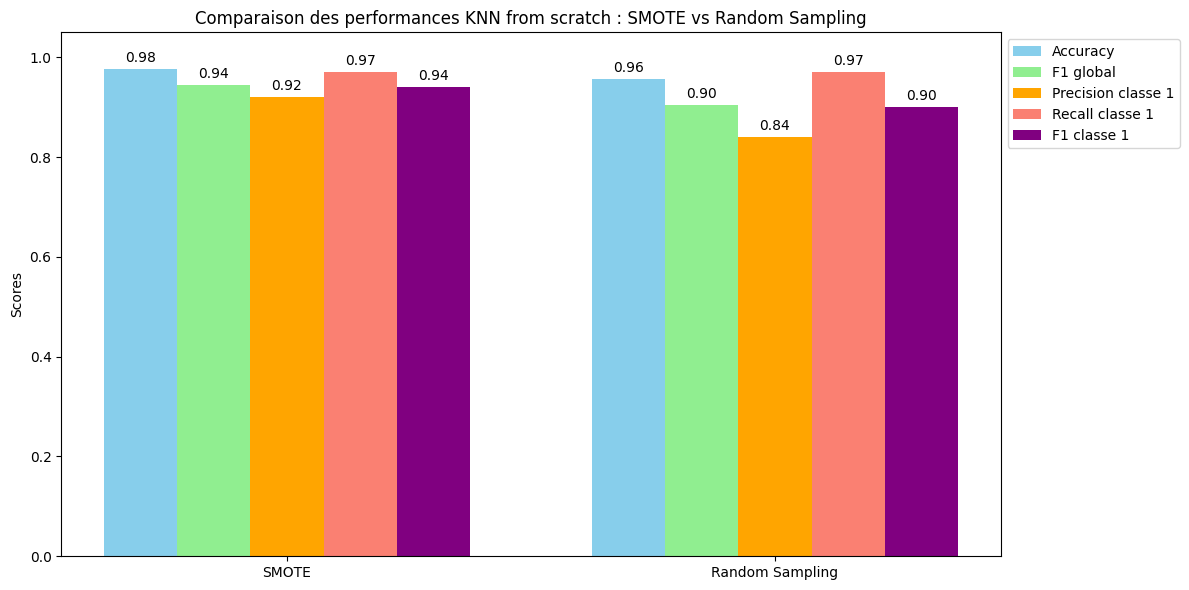

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Méthodes
methods = ['SMOTE', 'Random Sampling']

# Scores pour la classe 0 et classe 1
precision_0 = [0.99, 0.99]
precision_1 = [0.92, 0.84]

recall_0 = [0.98, 0.95]
recall_1 = [0.97, 0.97]

f1_0 = [0.98, 0.97]
f1_1 = [0.94, 0.90]

# Accuracy globale et F1-score global
accuracy = [0.975965, 0.956907]
f1_global = [0.943488, 0.903581]

# Création d'un graphique à barres multiples
x = np.arange(len(methods))  # positions des barres
width = 0.15  # largeur des barres

fig, ax = plt.subplots(figsize=(12,6))

# Barres pour Accuracy et F1 global
rects1 = ax.bar(x - 2*width, accuracy, width, label='Accuracy', color='skyblue')
rects2 = ax.bar(x - width, f1_global, width, label='F1 global', color='lightgreen')

# Barres pour Precision, Recall, F1 par classe
rects3 = ax.bar(x, precision_1, width, label='Precision classe 1', color='orange')
rects4 = ax.bar(x + width, recall_1, width, label='Recall classe 1', color='salmon')
rects5 = ax.bar(x + 2*width, f1_1, width, label='F1 classe 1', color='purple')

# Ajouter labels et titre
ax.set_ylabel('Scores')
ax.set_title('Comparaison des performances KNN from scratch : SMOTE vs Random Sampling')
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.set_ylim(0, 1.05)
ax.legend(loc='upper left', bbox_to_anchor=(1,1))

# Ajouter les valeurs au-dessus des barres
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width()/2, height),
                    xytext=(0,3),
                    textcoords="offset points",
                    ha='center', va='bottom')

for r in [rects1, rects2, rects3, rects4, rects5]:
    autolabel(r)

plt.tight_layout()
plt.show()


In [ ]:
class KNN:
    def __init__(self, k=5):
        self.k = k

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        predictions = []
        for x in X:
            # Compute Euclidean distances to all training points
            distances = np.sqrt(np.sum((self.X_train - x)**2, axis=1))

            # Find the indices of k nearest neighbors
            k_indices = np.argsort(distances)[:self.k]
            k_labels = self.y_train[k_indices]

            # Majority vote
            most_common = Counter(k_labels).most_common(1)[0][0]
            predictions.append(most_common)
        return np.array(predictions)


In [ ]:
# =========================
# KD-Tree Node
# =========================
class KDNode:
    def __init__(self, point=None, label=None, left=None, right=None, axis=0):
        self.point = point      # feature vector
        self.label = label      # target
        self.left = left        # left subtree
        self.right = right      # right subtree
        self.axis = axis        # splitting axis

# =========================
# KD-Tree Build
# =========================
def build_kdtree(X, y, depth=0):
    if len(X) == 0:
        return None
    k = X.shape[1]  # number of features
    axis = depth % k
    sorted_idx = X[:, axis].argsort()
    X = X[sorted_idx]
    y = y[sorted_idx]
    median_idx = len(X) // 2
    return KDNode(
        point=X[median_idx],
        label=y[median_idx],
        left=build_kdtree(X[:median_idx], y[:median_idx], depth+1),
        right=build_kdtree(X[median_idx+1:], y[median_idx+1:], depth+1),
        axis=axis
    )

# =========================
# KNN Query with KD-Tree
# =========================
def knn_query(node, x, k, heap):
    if node is None:
        return

    # Compute distance to current node
    dist = np.linalg.norm(x - node.point)

    # Maintain max-heap of k closest points
    if len(heap) < k:
        heap.append((dist, node.label))
        heap.sort(reverse=True)  # max-heap by distance
    elif dist < heap[0][0]:
        heap[0] = (dist, node.label)
        heap.sort(reverse=True)

    # Decide which subtree to visit first
    axis = node.axis
    diff = x[axis] - node.point[axis]

    first = node.left if diff < 0 else node.right
    second = node.right if diff < 0 else node.left

    knn_query(first, x, k, heap)

    # Check if we need to explore the other side
    if len(heap) < k or abs(diff) < heap[0][0]:
        knn_query(second, x, k, heap)

# =========================
# KD-Tree KNN Classifier
# =========================
class KDTreeKNN:
    def __init__(self, k=5):
        self.k = k
        self.tree = None

    def fit(self, X, y):
        self.tree = build_kdtree(np.array(X), np.array(y))

    def predict(self, X):
        preds = []
        for x in X:
            heap = []
            knn_query(self.tree, np.array(x), self.k, heap)
            labels = [label for _, label in heap]
            most_common = Counter(labels).most_common(1)[0][0]
            preds.append(most_common)
        return np.array(preds)


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

param_grid = {
    'n_neighbors': [3, 5],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}


In [ ]:
knn = KNeighborsClassifier(algorithm='kd_tree')

### Grid search with cross-validation

In [ ]:
n_samples = 10000
indices = np.random.choice(len(X_train_res), size=n_samples, replace=False)

X_sample = X_train_res[indices]
y_sample = y_train_res[indices]
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_sample, y_sample)


GridSearchCV(cv=5, estimator=KNeighborsClassifier(algorithm='kd_tree'),
             n_jobs=-1,
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': [3, 5],
                         'weights': ['uniform', 'distance']},
             scoring='f1')

In [ ]:
import pandas as pd

results = pd.DataFrame(grid_search.cv_results_)


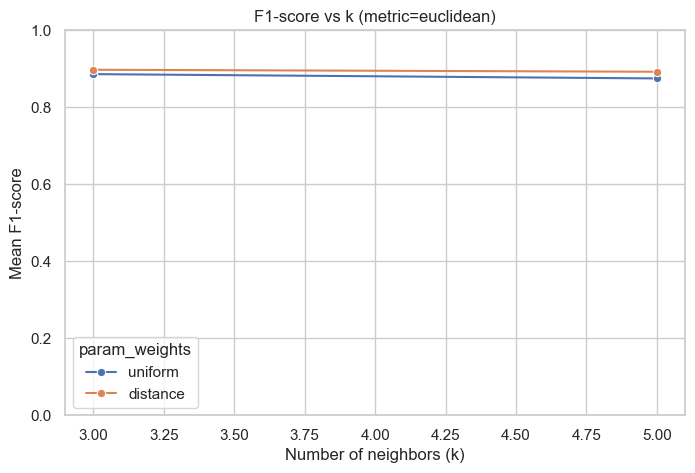

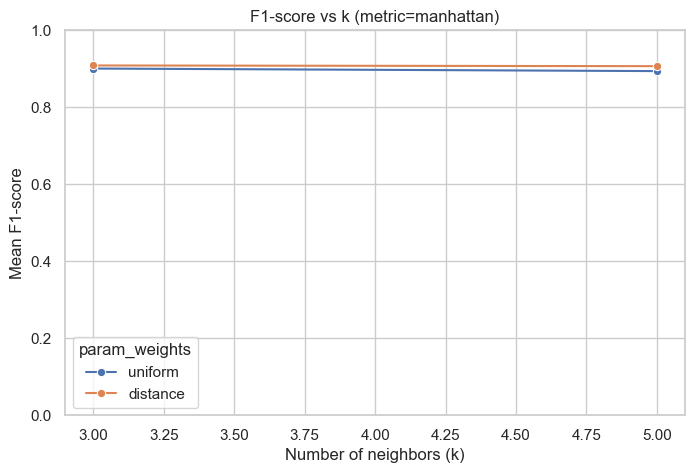

In [ ]:
import seaborn as sns

sns.set(style="whitegrid")

# Filter for one metric at a time if needed
for metric in results['param_metric'].unique():
    df_metric = results[results['param_metric'] == metric]
    plt.figure(figsize=(8,5))
    sns.lineplot(data=df_metric, x='param_n_neighbors', y='mean_test_score', hue='param_weights', marker='o')
    plt.title(f'F1-score vs k (metric={metric})')
    plt.xlabel('Number of neighbors (k)')
    plt.ylabel('Mean F1-score')
    plt.ylim(0,1)
    plt.show()

In [ ]:
print("Best parameters:", grid_search.best_params_)
print("Best F1-score:", grid_search.best_score_)


Best parameters: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
Best F1-score: 0.9085364562190605


In [ ]:
best_knn = grid_search.best_estimator_

# Train on the full (resampled/balanced) training set
best_knn.fit(X_train_res, y_train_res)

# Predict on the test set
y_pred = best_knn.predict(X_test)

c:\Users\HOME\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


In [ ]:
# Evaluate
from sklearn.metrics import accuracy_score, f1_score, classification_report
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9759301566579635
F1 Score: 0.9433827763002769
              precision    recall  f1-score   support

           0       0.99      0.98      0.98     67994
           1       0.92      0.97      0.94     17798

    accuracy                           0.98     85792
   macro avg       0.96      0.97      0.96     85792
weighted avg       0.98      0.98      0.98     85792



In [ ]:
# Sauvegarde des prédictions KNN SMOTE
knn_smote_pred_path = "data/processed/y_pred_knn_smote.pkl"
with open(knn_smote_pred_path, "wb") as f:
    pickle.dump(y_pred, f)
print(f"y_pred KNN SMOTE saved at {knn_smote_pred_path}")


y_pred KNN SMOTE saved at data/processed/y_pred_knn_smote.pkl


## knn for methode 2: random undersampling

### Grid search with cross-validation

In [ ]:
len(X_train_res2)


142388

In [ ]:
n_samples = 10000
indices = np.random.choice(len(X_train_res2), size=n_samples, replace=False)

X_sample2 = X_train_res2[indices]
y_sample2 = y_train_res2[indices]
grid_search2 = GridSearchCV(knn, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search2.fit(X_sample2, y_sample2)



GridSearchCV(cv=5, estimator=KNeighborsClassifier(algorithm='kd_tree'),
             n_jobs=-1,
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': [3, 5],
                         'weights': ['uniform', 'distance']},
             scoring='f1')

In [ ]:
import pandas as pd

results2 = pd.DataFrame(grid_search2.cv_results_)


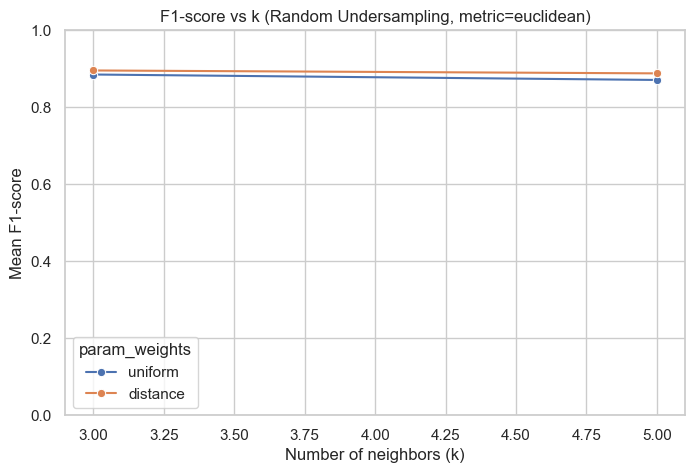

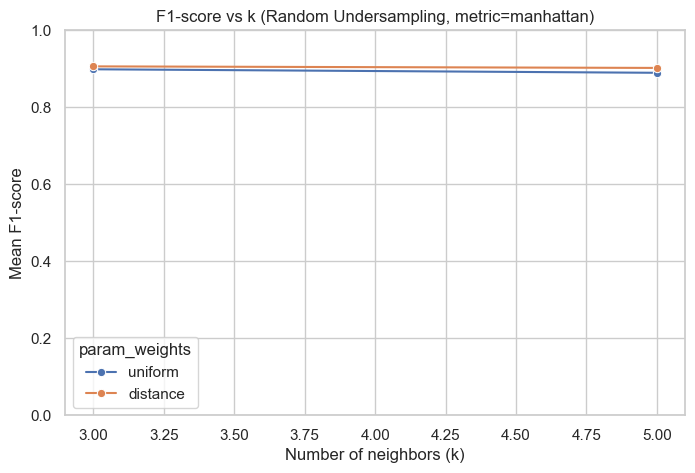

In [ ]:
sns.set(style="whitegrid")

# Affichage des courbes F1-score vs k pour chaque métrique
for metric in results2['param_metric'].unique():
    df_metric = results2[results2['param_metric'] == metric]
    plt.figure(figsize=(8,5))
    sns.lineplot(data=df_metric, x='param_n_neighbors', y='mean_test_score',
                 hue='param_weights', marker='o')
    plt.title(f'F1-score vs k (Random Undersampling, metric={metric})')
    plt.xlabel('Number of neighbors (k)')
    plt.ylabel('Mean F1-score')
    plt.ylim(0,1)
    plt.show()

In [ ]:
# Meilleurs paramètres et meilleur score
print("Best parameters (RUS):", grid_search2.best_params_)
print("Best F1-score (RUS):", grid_search2.best_score_)

Best parameters (RUS): {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
Best F1-score (RUS): 0.906161504690685


In [ ]:
# Meilleur modèle KNN pour Random Undersampling
best_knn_rus = grid_search2.best_estimator_

# Entraînement sur l'ensemble complet sous-échantillonné
best_knn_rus.fit(X_train_res2, y_train_res2)

# Prédictions sur le test set
y_pred_rus = best_knn_rus.predict(X_test)

c:\Users\HOME\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


In [ ]:
# Évaluation
from sklearn.metrics import accuracy_score, f1_score, classification_report
print("Accuracy (RUS):", accuracy_score(y_test, y_pred_rus))
print("F1 Score (RUS):", f1_score(y_test, y_pred_rus))
print(classification_report(y_test, y_pred_rus))

Accuracy (RUS): 0.957222118612458
F1 Score (RUS): 0.9042025580788305
              precision    recall  f1-score   support

           0       0.99      0.95      0.97     67994
           1       0.84      0.97      0.90     17798

    accuracy                           0.96     85792
   macro avg       0.92      0.96      0.94     85792
weighted avg       0.96      0.96      0.96     85792



In [ ]:
# Sauvegarde des prédictions KNN RUS
knn_rus_pred_path = "data/processed/y_pred_knn_rus.pkl"
with open(knn_rus_pred_path, "wb") as f:
    pickle.dump(y_pred_rus, f)
print(f"y_pred KNN RUS saved at {knn_rus_pred_path}")


y_pred KNN RUS saved at data/processed/y_pred_knn_rus.pkl


## Comparaison des deux methodes avec knn

Comparaison des performances KNN :
                 Method  Accuracy  F1 Score  Precision    Recall
0                 SMOTE  0.975930  0.943383   0.921232  0.966625
1  Random Undersampling  0.957222  0.904203   0.844384  0.973143


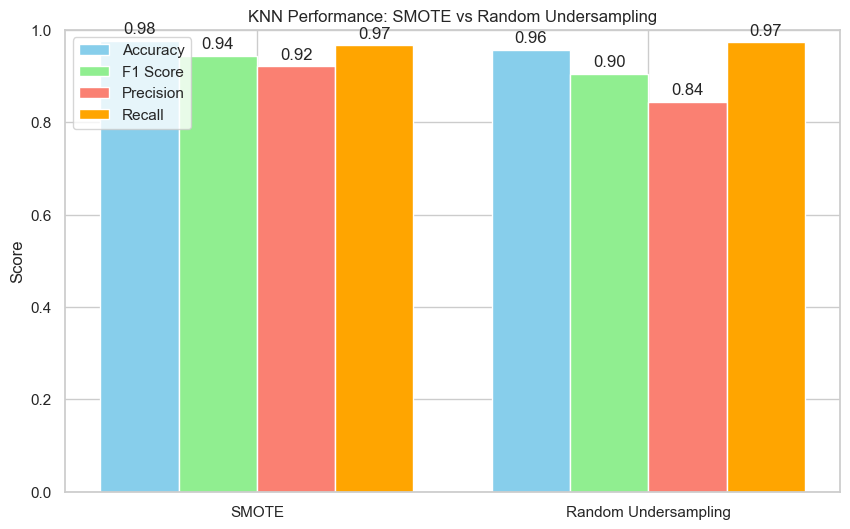

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Calcul des scores
methods = ['SMOTE', 'Random Undersampling']

accuracy_scores = [accuracy_score(y_test, y_pred), accuracy_score(y_test, y_pred_rus)]
f1_scores = [f1_score(y_test, y_pred), f1_score(y_test, y_pred_rus)]
precision_scores = [precision_score(y_test, y_pred), precision_score(y_test, y_pred_rus)]
recall_scores = [recall_score(y_test, y_pred), recall_score(y_test, y_pred_rus)]

# Création d'un DataFrame pour comparaison
comparison_df = pd.DataFrame({
    'Method': methods,
    'Accuracy': accuracy_scores,
    'F1 Score': f1_scores,
    'Precision': precision_scores,
    'Recall': recall_scores
})

print("Comparaison des performances KNN :")
print(comparison_df)

# Visualisation graphique
x = np.arange(len(methods))  # position des méthodes sur l'axe x
width = 0.2  # largeur des barres

fig, ax = plt.subplots(figsize=(10,6))

rects1 = ax.bar(x - 1.5*width, accuracy_scores, width, label='Accuracy', color='skyblue')
rects2 = ax.bar(x - 0.5*width, f1_scores, width, label='F1 Score', color='lightgreen')
rects3 = ax.bar(x + 0.5*width, precision_scores, width, label='Precision', color='salmon')
rects4 = ax.bar(x + 1.5*width, recall_scores, width, label='Recall', color='orange')

ax.set_ylabel('Score')
ax.set_ylim(0,1)
ax.set_title('KNN Performance: SMOTE vs Random Undersampling')
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.legend()

# Affichage des valeurs sur les barres
for rects in [rects1, rects2, rects3, rects4]:
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

plt.show()


### Comparaison KNN FROM SCRATCH VS KNN SKLEARN

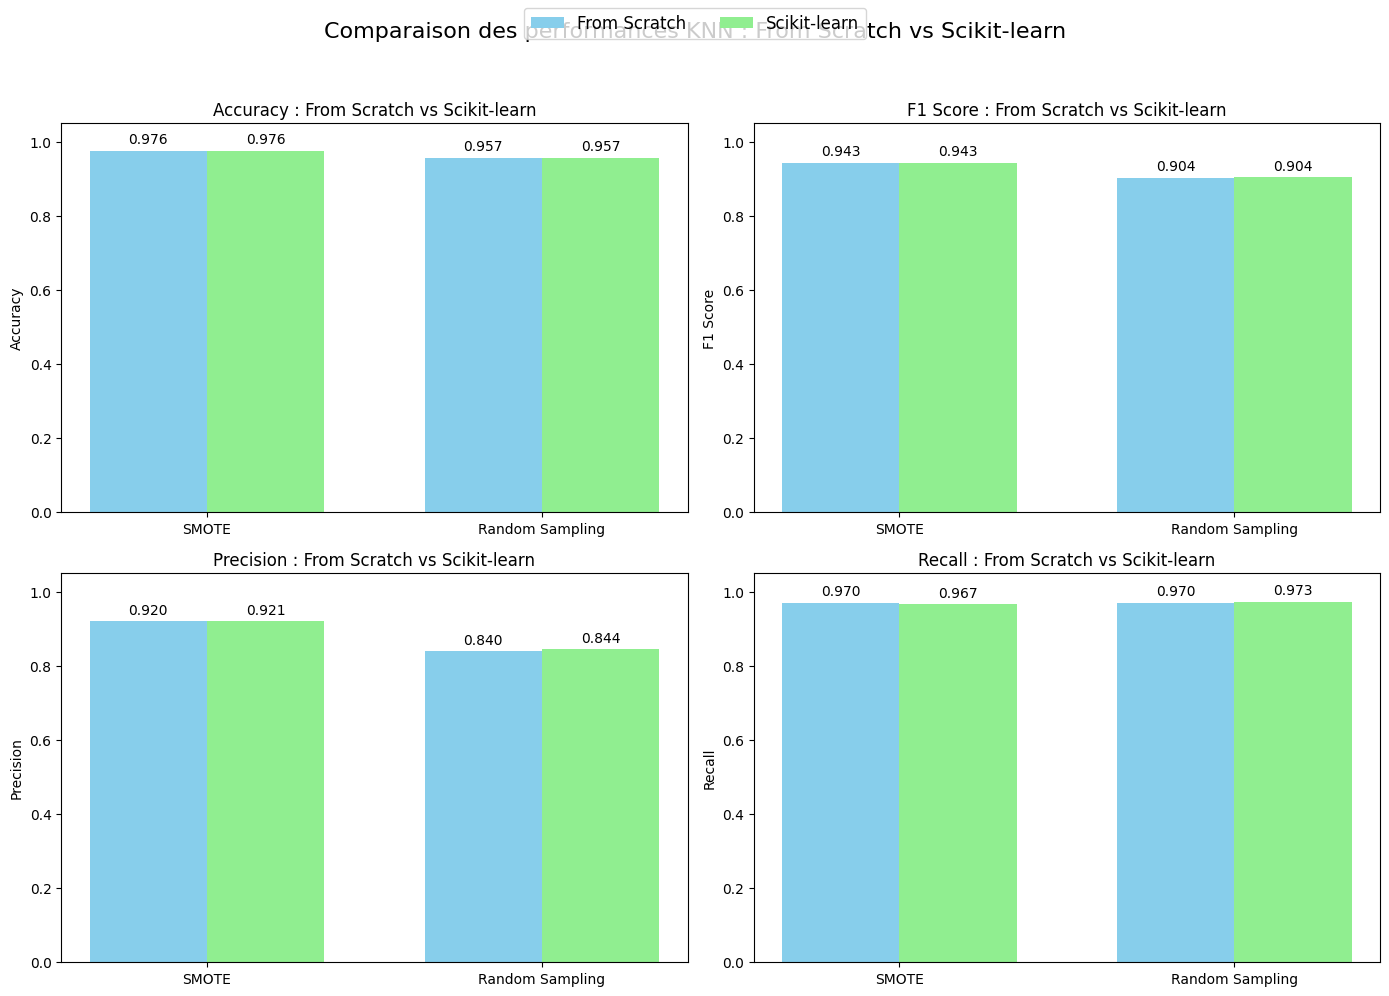

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Méthodes
methods = ['SMOTE', 'Random Sampling']
x = np.arange(len(methods))  # positions
width = 0.35  # largeur des barres

# Scores from scratch
accuracy_fs = [0.975965, 0.956907]
f1_fs = [0.943488, 0.903581]
precision_fs = [0.92, 0.84]
recall_fs = [0.97, 0.97]

# Scores sklearn
accuracy_sk = [0.975930, 0.957222]
f1_sk = [0.943383, 0.904203]
precision_sk = [0.921232, 0.844384]
recall_sk = [0.966625, 0.973143]

# Liste des scores et titres
fs_scores_list = [accuracy_fs, f1_fs, precision_fs, recall_fs]
sk_scores_list = [accuracy_sk, f1_sk, precision_sk, recall_sk]
metrics = ['Accuracy', 'F1 Score', 'Precision', 'Recall']

# Création d'une figure avec 4 subplots
fig, axs = plt.subplots(2, 2, figsize=(14,10))
axs = axs.flatten()

for i, ax in enumerate(axs):
    rects1 = ax.bar(x - width/2, fs_scores_list[i], width, label='From Scratch', color='skyblue')
    rects2 = ax.bar(x + width/2, sk_scores_list[i], width, label='Scikit-learn', color='lightgreen')

    ax.set_ylabel(metrics[i])
    ax.set_title(f'{metrics[i]} : From Scratch vs Scikit-learn')
    ax.set_xticks(x)
    ax.set_xticklabels(methods)
    ax.set_ylim(0, 1.05)

    # Ajouter valeurs sur les barres
    for rects in [rects1, rects2]:
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.3f}',
                        xy=(rect.get_x() + rect.get_width()/2, height),
                        xytext=(0,3),
                        textcoords="offset points",
                        ha='center', va='bottom')

# Légende commune
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, fontsize=12)

plt.suptitle('Comparaison des performances KNN : From Scratch vs Scikit-learn', fontsize=16)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()


## Decision tree algo

### DecisionTree from scratch

In [ ]:
class DecisionTree:
    def __init__(self, max_depth=5, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree = None

    # Gini Impurity
    def gini(self, y):
        m = len(y)
        counts = np.bincount(y)
        probabilities = counts / m
        return 1 - np.sum(probabilities ** 2)

    # Split the dataset
    def split(self, X, y, feature_index, threshold):
        left_mask = X[:, feature_index] <= threshold
        right_mask = X[:, feature_index] > threshold
        return X[left_mask], y[left_mask], X[right_mask], y[right_mask]

    # Best split (milieux des valeurs triées)
    def best_split(self, X, y):
        m, n = X.shape
        best_gini = 1
        best_feature, best_threshold = None, None

        for feature_index in range(n):
            # Trier les valeurs de la feature
            sorted_values = np.sort(np.unique(X[:, feature_index]))
            # Calculer les milieux entre valeurs consécutives
            thresholds = (sorted_values[:-1] + sorted_values[1:]) / 2  # optimisation

            for t in thresholds:
                X_left, y_left, X_right, y_right = self.split(X, y, feature_index, t)
                if len(y_left) == 0 or len(y_right) == 0:
                    continue
                gini_left = self.gini(y_left)
                gini_right = self.gini(y_right)
                gini_split = (len(y_left) * gini_left + len(y_right) * gini_right) / m
                if gini_split < best_gini:
                    best_gini = gini_split
                    best_feature = feature_index
                    best_threshold = t
        return best_feature, best_threshold

    # Build tree recursively
    def build_tree(self, X, y, depth=0):
        if len(set(y)) == 1 or depth >= self.max_depth or len(y) < self.min_samples_split:
            return Counter(y).most_common(1)[0][0]

        feature, threshold = self.best_split(X, y)
        if feature is None:
            return Counter(y).most_common(1)[0][0]

        X_left, y_left, X_right, y_right = self.split(X, y, feature, threshold)
        left_tree = self.build_tree(X_left, y_left, depth + 1)
        right_tree = self.build_tree(X_right, y_right, depth + 1)

        return {"feature": feature, "threshold": threshold, "left": left_tree, "right": right_tree}

    def fit(self, X, y):
        self.tree = self.build_tree(X, y)

    # Predict one sample
    def predict_one(self, x, node):
        if not isinstance(node, dict):
            return node
        if x[node['feature']] <= node['threshold']:
            return self.predict_one(x, node['left'])
        else:
            return self.predict_one(x, node['right'])

    def predict(self, X):
        return np.array([self.predict_one(x, self.tree) for x in X])


In [ ]:
import numpy as np
from collections import Counter

class DecisionTreeScratch:
    def __init__(self, max_depth=5, min_samples_split=10, max_features=None, n_thresholds=20, verbose=0):
        """
        max_depth: max depth of tree
        min_samples_split: min samples to split
        max_features: max features to consider per split (None = all)
        n_thresholds: number of thresholds to try per feature
        verbose: 0 = silent, 1 = print tree building info
        """
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.n_thresholds = n_thresholds
        self.verbose = verbose
        self.tree = None

    # Gini impurity (vectorized)
    def gini(self, y):
        if len(y) == 0:
            return 0
        counts = np.bincount(y, minlength=np.max(y)+1)
        probs = counts / len(y)
        return 1 - np.sum(probs ** 2)

    # Best split with threshold subsampling
    def best_split(self, X, y):
        m, n = X.shape
        best_gini = 1
        best_feature = None
        best_threshold = None

        # Random feature subset if max_features is set
        features = np.arange(n)
        if self.max_features is not None:
            features = np.random.choice(n, self.max_features, replace=False)

        for feature_index in features:
            X_feature = X[:, feature_index]
            unique_vals = np.unique(X_feature)
            if len(unique_vals) <= 1:
                continue
            # Subsample thresholds for speed
            thresholds = np.linspace(unique_vals[0], unique_vals[-1], min(self.n_thresholds, len(unique_vals)))

            for t in thresholds:
                left_mask = X_feature <= t
                right_mask = X_feature > t

                if left_mask.sum() < self.min_samples_split or right_mask.sum() < self.min_samples_split:
                    continue

                y_left = y[left_mask]
                y_right = y[right_mask]

                gini_split = (len(y_left)*self.gini(y_left) + len(y_right)*self.gini(y_right)) / m

                if gini_split < best_gini:
                    best_gini = gini_split
                    best_feature = feature_index
                    best_threshold = t

        return best_feature, best_threshold

    # Recursive tree building
    def build_tree(self, X, y, depth=0):
        # Leaf condition
        leaf_value = Counter(y).most_common(1)[0][0]
        if len(set(y)) == 1 or depth >= self.max_depth or len(y) < self.min_samples_split:
            if self.verbose:
                print(f"{'|   '*depth}Leaf: {leaf_value} (samples={len(y)})")
            return {"value": leaf_value}

        feature, threshold = self.best_split(X, y)
        if feature is None:
            if self.verbose:
                print(f"{'|   '*depth}Leaf (no split): {leaf_value} (samples={len(y)})")
            return {"value": leaf_value}

        if self.verbose:
            print(f"{'|   '*depth}Node: feature={feature}, threshold={threshold:.4f}, samples={len(y)}")

        left_mask = X[:, feature] <= threshold
        right_mask = X[:, feature] > threshold

        left_tree = self.build_tree(X[left_mask], y[left_mask], depth + 1)
        right_tree = self.build_tree(X[right_mask], y[right_mask], depth + 1)

        return {
            "feature": feature,
            "threshold": threshold,
            "left": left_tree,
            "right": right_tree,
            "value": leaf_value  # safe fallback at any node
        }

    def fit(self, X, y):
        self.tree = self.build_tree(X, y)

    # Safe prediction for one sample
    def predict_one(self, x, node):
        if not isinstance(node, dict):
            return node
        # Safety check: fallback if feature index is out of bounds
        feature_idx = node.get('feature', None)
        if feature_idx is None or feature_idx >= len(x):
            return node['value']
        if x[feature_idx] <= node['threshold']:
            return self.predict_one(x, node['left'])
        else:
            return self.predict_one(x, node['right'])

    def predict(self, X):
        return np.array([self.predict_one(x, self.tree) for x in X])



In [ ]:
X_test.dtypes


,0
prec_winter,float64
prec_spring,float64
prec_summer,float64
prec_fall,float64
tmax_winter,float64
tmax_spring,float64
tmax_summer,float64
tmax_fall,float64
tmin_winter,float64
tmin_spring,float64


execution avec smote


In [ ]:
# 1️⃣ Import necessary libraries
import numpy as np
from collections import Counter
from sklearn.metrics import accuracy_score, f1_score, classification_report

# 3️⃣ Create the tree instance
dt_scratch = DecisionTreeScratch(
    max_depth=8,
    min_samples_split=10,
    n_thresholds=30,   # number of thresholds per feature
    max_features=20,
    verbose=1
)

# 4️⃣ Train the model
dt_scratch.fit(X_train_res, y_train_res)

# 5️⃣ Make predictions
y_pred_scratch = dt_scratch.predict(X_test)

# 6️⃣ Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred_scratch))
print("F1 Score:", f1_score(y_test, y_pred_scratch))
print(classification_report(y_test, y_pred_scratch))


Node: feature=12, threshold=276.6897, samples=543946
|   Node: feature=11, threshold=0.7577, samples=225883
|   |   Node: feature=6, threshold=-1.8764, samples=87066
|   |   |   Node: feature=12, threshold=83.5862, samples=29053
|   |   |   |   Node: feature=9, threshold=-0.7836, samples=23887
|   |   |   |   |   Node: feature=57, threshold=-1.0073, samples=23448
|   |   |   |   |   |   Node: feature=1, threshold=2.3751, samples=137
|   |   |   |   |   |   |   Leaf: 0 (samples=40)
|   |   |   |   |   |   |   Node: feature=12, threshold=22.3448, samples=97
|   |   |   |   |   |   |   |   Leaf: 0 (samples=36)
|   |   |   |   |   |   |   |   Leaf: 0 (samples=61)
|   |   |   |   |   |   Node: feature=23, threshold=0.6460, samples=23311
|   |   |   |   |   |   |   Node: feature=44, threshold=11.1365, samples=23176
|   |   |   |   |   |   |   |   Leaf: 1 (samples=23087)
|   |   |   |   |   |   |   |   Leaf: 0 (samples=89)
|   |   |   |   |   |   |   Node: feature=13, threshold=-1.3477, sampl

execution avec random undersampling

In [ ]:
# 1️⃣ Import necessary libraries
import numpy as np
from collections import Counter
from sklearn.metrics import accuracy_score, f1_score, classification_report

# 3️⃣ Create the tree instance
dt_scratch = DecisionTreeScratch(
    max_depth=8,
    min_samples_split=10,
    n_thresholds=30,   # number of thresholds per feature
    max_features=20,
    verbose=1
)

# 4️⃣ Train the model
dt_scratch.fit(X_train_res2, y_train_res2)

# 5️⃣ Make predictions
y_pred_scratch2 = dt_scratch.predict(X_test)

# 6️⃣ Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred_scratch2))
print("F1 Score:", f1_score(y_test, y_pred_scratch2))
print(classification_report(y_test, y_pred_scratch2))

Node: feature=11, threshold=0.8293, samples=142388
|   Node: feature=8, threshold=-1.2200, samples=100905
|   |   Node: feature=5, threshold=-2.1721, samples=11154
|   |   |   Node: feature=4, threshold=-2.2759, samples=2172
|   |   |   |   Node: feature=15, threshold=2.0250, samples=1572
|   |   |   |   |   Node: feature=2, threshold=2.4611, samples=880
|   |   |   |   |   |   Node: feature=57, threshold=0.6194, samples=746
|   |   |   |   |   |   |   Node: feature=1, threshold=1.8537, samples=510
|   |   |   |   |   |   |   |   Leaf: 0 (samples=299)
|   |   |   |   |   |   |   |   Leaf: 0 (samples=211)
|   |   |   |   |   |   |   Node: feature=7, threshold=-2.3583, samples=236
|   |   |   |   |   |   |   |   Leaf: 0 (samples=105)
|   |   |   |   |   |   |   |   Leaf: 0 (samples=131)
|   |   |   |   |   |   Node: feature=11, threshold=-2.3769, samples=134
|   |   |   |   |   |   |   Leaf: 0 (samples=65)
|   |   |   |   |   |   |   Node: feature=35, threshold=-0.1663, samples=69
|   | 

### execution with sklearn


#### avec SMOTE

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Assuming X_train_res, y_train_res are your training data (after SMOTE)
# and X_test, y_test are your test data

# Create the Decision Tree classifier
dt = DecisionTreeClassifier(max_depth=8, min_samples_split=10, random_state=42)

# Train the model
dt.fit(X_train_res, y_train_res)

# Make predictions
y_pred_dct = dt.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred_dct))
print("F1 Score:", f1_score(y_test, y_pred_dct))
print(classification_report(y_test, y_pred_dct))


Accuracy: 0.9096069563595673
F1 Score: 0.8121957716804301
              precision    recall  f1-score   support

           0       0.98      0.90      0.94     67994
           1       0.71      0.94      0.81     17798

    accuracy                           0.91     85792
   macro avg       0.85      0.92      0.88     85792
weighted avg       0.93      0.91      0.91     85792



c:\Users\HOME\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


In [ ]:
# Sauvegarde des prédictions Decision Tree SMOTE
dt_smote_pred_path = "data/processed/y_pred_dt_smote.pkl"
with open(dt_smote_pred_path, "wb") as f:
    pickle.dump(y_pred_dct, f)
print(f"y_pred Decision Tree SMOTE saved at {dt_smote_pred_path}")


y_pred Decision Tree SMOTE saved at data/processed/y_pred_dt_smote.pkl


#### avec random undersampling

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Create the Decision Tree classifier
dt = DecisionTreeClassifier(max_depth=8, min_samples_split=10, random_state=42)

# Train the model
dt.fit(X_train_res2, y_train_res2)

# Make predictions
y_pred_dct2 = dt.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred_dct2))
print("F1 Score:", f1_score(y_test, y_pred_dct2))
print(classification_report(y_test, y_pred_dct2))


Accuracy: 0.9100615441999254
F1 Score: 0.8126911686167888
              precision    recall  f1-score   support

           0       0.98      0.90      0.94     67994
           1       0.72      0.94      0.81     17798

    accuracy                           0.91     85792
   macro avg       0.85      0.92      0.88     85792
weighted avg       0.93      0.91      0.91     85792



c:\Users\HOME\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


In [ ]:
# Sauvegarde des prédictions Decision Tree RUS
dt_rus_pred_path = "data/processed/y_pred_dt_rus.pkl"
with open(dt_rus_pred_path, "wb") as f:
    pickle.dump(y_pred_dct2, f)
print(f"y_pred Decision Tree RUS saved at {dt_rus_pred_path}")


y_pred Decision Tree RUS saved at data/processed/y_pred_dt_rus.pkl


## Comparasion des deux methodes avec DecisionTree

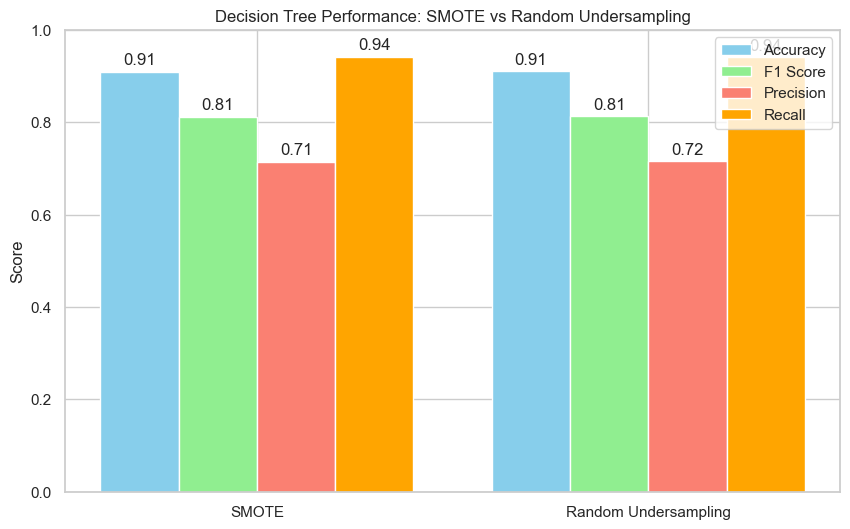

In [ ]:
from sklearn.metrics import precision_score, recall_score
import matplotlib.pyplot as plt
import numpy as np

# Scores pour les deux méthodes
methods = ['SMOTE', 'Random Undersampling']

accuracy_scores = [accuracy_score(y_test, y_pred_dct), accuracy_score(y_test, y_pred_dct2)]
f1_scores = [f1_score(y_test, y_pred_dct), f1_score(y_test, y_pred_dct2)]
precision_scores = [precision_score(y_test, y_pred_dct), precision_score(y_test, y_pred_dct2)]
recall_scores = [recall_score(y_test, y_pred_dct), recall_score(y_test, y_pred_dct2)]

x = np.arange(len(methods))  # position des méthodes sur l'axe x
width = 0.2  # largeur des barres

fig, ax = plt.subplots(figsize=(10,6))

# Barres pour chaque métrique
rects1 = ax.bar(x - 1.5*width, accuracy_scores, width, label='Accuracy', color='skyblue')
rects2 = ax.bar(x - 0.5*width, f1_scores, width, label='F1 Score', color='lightgreen')
rects3 = ax.bar(x + 0.5*width, precision_scores, width, label='Precision', color='salmon')
rects4 = ax.bar(x + 1.5*width, recall_scores, width, label='Recall', color='orange')

# Labels et titres
ax.set_ylabel('Score')
ax.set_ylim(0,1)
ax.set_title('Decision Tree Performance: SMOTE vs Random Undersampling')
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.legend()

# Afficher les valeurs sur les barres
for rects in [rects1, rects2, rects3, rects4]:
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

plt.show()


comparison scratch with sklearn

/tmp/ipython-input-2884817581.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Method", y="Accuracy", data=df_results, palette="Blues_d")


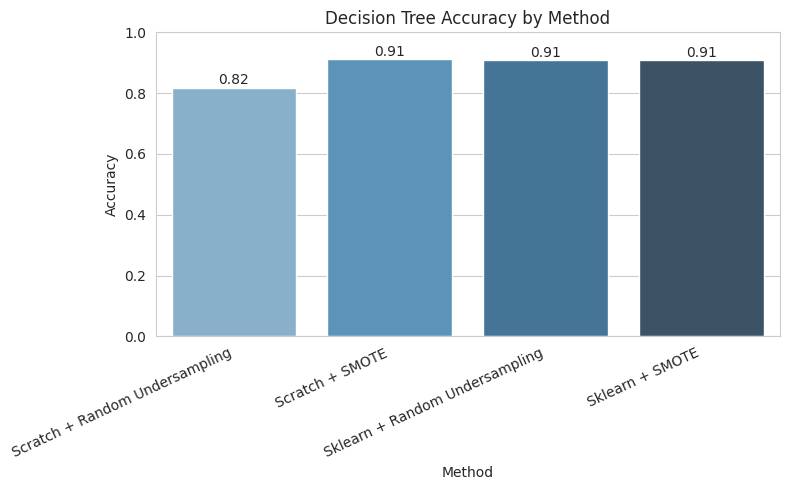

/tmp/ipython-input-2884817581.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Method", y="F1 Score", data=df_results, palette="Reds_d")


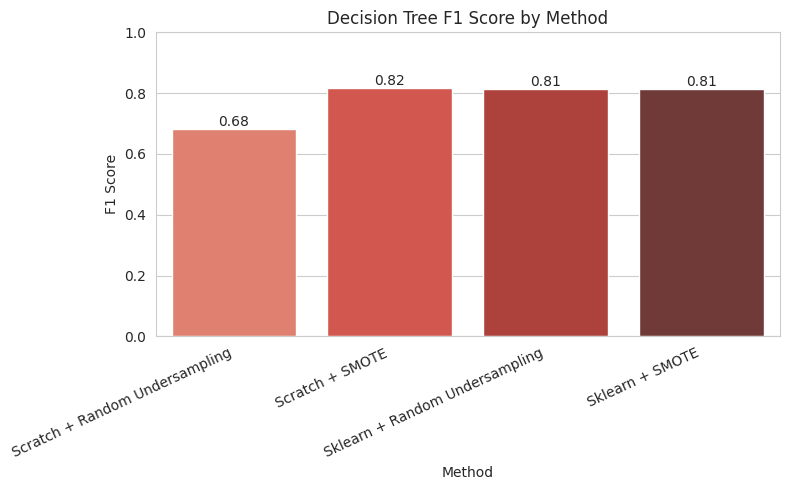

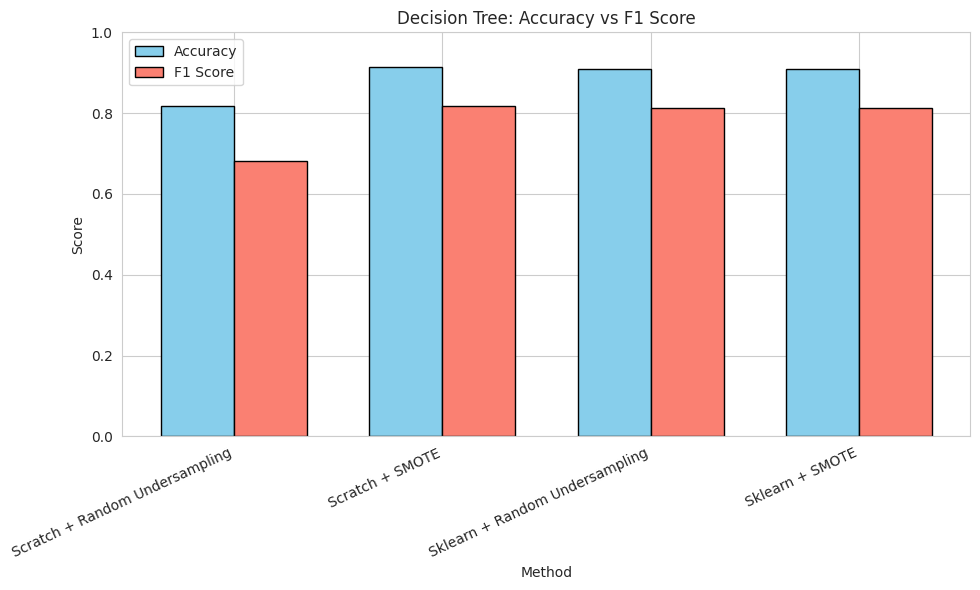

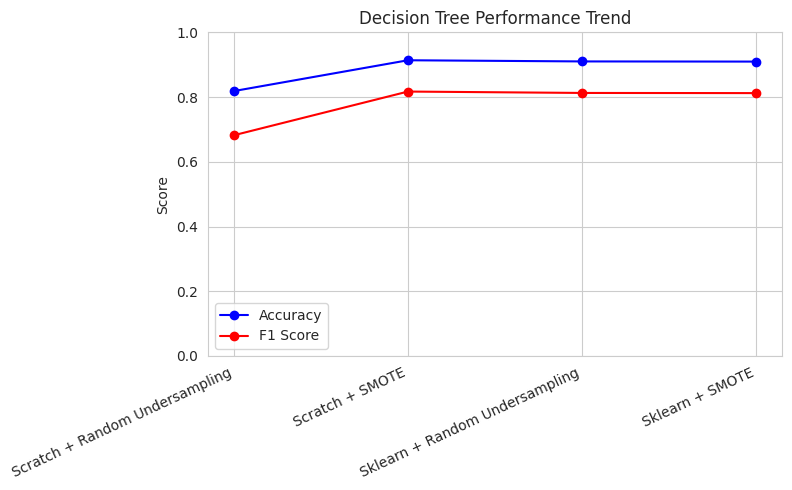

In [ ]:
results = {
    "Method": [
        "Scratch + Random Undersampling",
        "Scratch + SMOTE",
        "Sklearn + Random Undersampling",
        "Sklearn + SMOTE"
    ],
    "Accuracy": [
        0.8185,
        0.9137,
        0.9101,
        0.9096
    ],
    "F1 Score": [
        0.6820,
        0.8170,
        0.8127,
        0.8122
    ]
}

df_results = pd.DataFrame(results)

sns.set_style("whitegrid")

# 1️⃣ Bar plot: Accuracy only
plt.figure(figsize=(8,5))
sns.barplot(x="Method", y="Accuracy", data=df_results, palette="Blues_d")
plt.title("Decision Tree Accuracy by Method")
plt.ylim(0,1)
plt.xticks(rotation=25, ha='right')
for i, val in enumerate(df_results["Accuracy"]):
    plt.text(i, val + 0.01, f"{val:.2f}", ha='center')
plt.tight_layout()
plt.show()

# 2️⃣ Bar plot: F1 Score only
plt.figure(figsize=(8,5))
sns.barplot(x="Method", y="F1 Score", data=df_results, palette="Reds_d")
plt.title("Decision Tree F1 Score by Method")
plt.ylim(0,1)
plt.xticks(rotation=25, ha='right')
for i, val in enumerate(df_results["F1 Score"]):
    plt.text(i, val + 0.01, f"{val:.2f}", ha='center')
plt.tight_layout()
plt.show()

# 3️⃣ Grouped bar plot: Accuracy vs F1
plt.figure(figsize=(10,6))
bar_width = 0.35
r1 = range(len(df_results))
r2 = [x + bar_width for x in r1]

plt.bar(r1, df_results["Accuracy"], color='skyblue', width=bar_width, edgecolor='black', label='Accuracy')
plt.bar(r2, df_results["F1 Score"], color='salmon', width=bar_width, edgecolor='black', label='F1 Score')

plt.xlabel("Method")
plt.ylabel("Score")
plt.title("Decision Tree: Accuracy vs F1 Score")
plt.xticks([r + bar_width/2 for r in range(len(df_results))], df_results["Method"], rotation=25, ha='right')
plt.ylim(0,1)
plt.legend()
plt.tight_layout()
plt.show()

# 4️⃣ Line plot: Trends across methods
plt.figure(figsize=(8,5))
plt.plot(df_results["Method"], df_results["Accuracy"], marker='o', label='Accuracy', color='blue')
plt.plot(df_results["Method"], df_results["F1 Score"], marker='o', label='F1 Score', color='red')
plt.title("Decision Tree Performance Trend")
plt.ylim(0,1)
plt.xticks(rotation=25, ha='right')
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

From the results, we can observe several patterns:

The from-scratch decision tree performs slightly worse than sklearn when using random undersampling, achieving Accuracy ≈ 0.82 and F1 ≈ 0.68, compared to sklearn’s Accuracy ≈ 0.91 and F1 ≈ 0.81.

Applying SMOTE significantly improves the performance of the from-scratch tree, increasing Accuracy to ≈ 0.91 and F1 Score to ≈ 0.82, bringing it very close to sklearn’s results.

Overall, SMOTE helps the model handle the imbalanced classes much better, improving the recall of the minority class without compromising the majority class performance.

The sklearn implementation remains slightly more consistent, but the from-scratch model shows that with proper preprocessing and class balancing, a custom decision tree can achieve comparable results to professional libraries.

## Random Forest

### Random Forest from scratch

In [ ]:
import numpy as np
from collections import Counter
from tqdm import tqdm  # progress bar

class ScratchRandomForest:
    def __init__(self, n_trees=10, max_depth=5, min_samples_split=50, max_features='sqrt', n_thresholds=30, bootstrap=True, verbose=1):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.n_thresholds = n_thresholds  # number of candidate thresholds per feature
        self.bootstrap = bootstrap
        self.trees = []
        self.verbose = verbose

    # Gini
    def gini(self, y):
        if len(y) == 0:
            return 0
        counts = np.bincount(y)
        probs = counts / len(y)
        return 1 - np.sum(probs**2)

    # Split dataset fast
    def split(self, X, y, f_idx, threshold):
        mask = X[:, f_idx] <= threshold
        return X[mask], y[mask], X[~mask], y[~mask]

    # Best split (optimized)
    def best_split(self, X, y):
        m, n = X.shape
        best_gini = 1
        best_feature, best_threshold = None, None

        # Feature subsampling
        if self.max_features == 'sqrt':
            k = max(1, int(np.sqrt(n)))
            features_idx = np.random.choice(n, k, replace=False)
        elif isinstance(self.max_features, int):
            features_idx = np.random.choice(n, self.max_features, replace=False)
        else:
            features_idx = np.arange(n)

        for f in features_idx:
            unique_vals = np.unique(X[:, f])
            if len(unique_vals) <= 1:
                continue
            # Use n_thresholds random thresholds for speed
            if len(unique_vals) > self.n_thresholds:
                thresholds = np.random.choice(unique_vals, self.n_thresholds, replace=False)
            else:
                thresholds = (unique_vals[:-1] + unique_vals[1:]) / 2
            for t in thresholds:
                X_left, y_left, X_right, y_right = self.split(X, y, f, t)
                if len(y_left) < self.min_samples_split or len(y_right) < self.min_samples_split:
                    continue
                gini_split = (len(y_left)*self.gini(y_left) + len(y_right)*self.gini(y_right)) / m
                if gini_split < best_gini:
                    best_gini = gini_split
                    best_feature = f
                    best_threshold = t
        return best_feature, best_threshold

    # Recursive tree build
    def build_tree(self, X, y, depth=0):
        if len(set(y)) == 1 or depth >= self.max_depth or len(y) < self.min_samples_split:
            return Counter(y).most_common(1)[0][0]

        feature, threshold = self.best_split(X, y)
        if feature is None:
            return Counter(y).most_common(1)[0][0]

        X_left, y_left, X_right, y_right = self.split(X, y, feature, threshold)
        left_tree = self.build_tree(X_left, y_left, depth + 1)
        right_tree = self.build_tree(X_right, y_right, depth + 1)

        return {"feature": feature, "threshold": threshold, "left": left_tree, "right": right_tree}

    # Fit single tree
    def fit_tree(self, X, y):
        return self.build_tree(X, y)

    # Fit forest
    def fit(self, X, y):
        self.trees = []
        for i in tqdm(range(self.n_trees), desc="Building Random Forest"):
            if self.bootstrap:
                idxs = np.random.choice(len(X), len(X), replace=True)
                X_sample, y_sample = X[idxs], y[idxs]
            else:
                X_sample, y_sample = X, y
            tree = self.fit_tree(X_sample, y_sample)
            self.trees.append(tree)
            if self.verbose:
                print(f"Tree {i+1}/{self.n_trees} done.")

    # Predict one sample
    def predict_one_tree(self, x, node):
        if not isinstance(node, dict):
            return node
        if x[node['feature']] <= node['threshold']:
            return self.predict_one_tree(x, node['left'])
        else:
            return self.predict_one_tree(x, node['right'])

    # Predict all
    def predict(self, X):
        all_preds = np.zeros((X.shape[0], self.n_trees), dtype=int)
        for i, tree in enumerate(self.trees):
            all_preds[:, i] = [self.predict_one_tree(x, tree) for x in X]
        # Majority vote
        final_preds = [Counter(row).most_common(1)[0][0] for row in all_preds]
        return np.array(final_preds)



execution without imbalance

In [ ]:


rf = ScratchRandomForest(
    n_trees=100,             # match sklearn n_estimators
    min_samples_split=2,      # minimum samples to split
    max_features='sqrt',      # sqrt of features per split
    n_thresholds=30,          # limit candidate thresholds to speed up
    bootstrap=True,
    verbose=1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

# Evaluate
from sklearn.metrics import accuracy_score, f1_score, classification_report
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Building Random Forest:   1%|          | 1/100 [00:28<46:48, 28.37s/it]

Tree 1/100 done.


Building Random Forest:   2%|▏         | 2/100 [00:48<37:58, 23.25s/it]

Tree 2/100 done.


Building Random Forest:   3%|▎         | 3/100 [01:15<40:49, 25.25s/it]

...

Building Random Forest:  99%|█████████▉| 99/100 [47:28<00:28, 28.08s/it]

Tree 99/100 done.


Building Random Forest: 100%|██████████| 100/100 [47:59<00:00, 28.79s/it]

Tree 100/100 done.


Accuracy: 0.8657800261096605
F1 Score: 0.5631804559766321
              precision    recall  f1-score   support

           0       0.87      0.98      0.92     67994
           1       0.87      0.42      0.56     17798

    accuracy                           0.87     85792
   macro avg       0.87      0.70      0.74     85792
weighted avg       0.87      0.87      0.85     85792



avec smote

In [ ]:


rf_smote = ScratchRandomForest(
    n_trees=100,             # match sklearn n_estimators
    min_samples_split=2,      # minimum samples to split
    max_features='sqrt',      # sqrt of features per split
    n_thresholds=30,          # limit candidate thresholds to speed up
    bootstrap=True,
    verbose=1
)

rf_smote.fit(X_train_res, y_train_res)

y_pred_rf_smote = rf.predict(X_test)

# Evaluate
from sklearn.metrics import accuracy_score, f1_score, classification_report
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Building Random Forest:   1%|          | 1/100 [01:41<2:47:25, 101.47s/it]

Tree 1/100 done.


Building Random Forest:   2%|▏         | 2/100 [02:53<2:17:06, 83.94s/it] 

Tree 2/100 done.


Building Random Forest:   3%|▎         | 3/100 [04:22<2:19:39, 86.39s/it]

...

Building Random Forest:  99%|█████████▉| 99/100 [2:25:22<01:27, 87.19s/it]

Tree 99/100 done.


Building Random Forest: 100%|██████████| 100/100 [2:26:57<00:00, 88.18s/it]

Tree 100/100 done.


Accuracy: 0.8657800261096605
F1 Score: 0.5631804559766321
              precision    recall  f1-score   support

           0       0.87      0.98      0.92     67994
           1       0.87      0.42      0.56     17798

    accuracy                           0.87     85792
   macro avg       0.87      0.70      0.74     85792
weighted avg       0.87      0.87      0.85     85792



balanced from scratch

In [ ]:
import numpy as np
from collections import Counter

class ScratchBRandomForest:
    def __init__(self, n_trees=100, max_depth=None, min_samples_split=2,
                 max_features='sqrt', n_thresholds=30,
                 bootstrap=True, balanced=False, verbose=1):
        self.n_trees = n_trees
        self.max_depth = max_depth if max_depth is not None else 1_000_000
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.n_thresholds = n_thresholds  # number of candidate thresholds per feature
        self.bootstrap = bootstrap
        self.balanced = balanced
        self.verbose = verbose
        self.trees = []

    # -----------------------------
    # Gini Impurity
    # -----------------------------
    def gini(self, y):
        m = len(y)
        if m == 0:
            return 0
        counts = np.bincount(y)
        probabilities = counts / m
        return 1 - np.sum(probabilities ** 2)

    # -----------------------------
    # Split dataset
    # -----------------------------
    def split(self, X, y, feature_index, threshold):
        left_mask = X[:, feature_index] <= threshold
        right_mask = X[:, feature_index] > threshold
        return X[left_mask], y[left_mask], X[right_mask], y[right_mask]

    # -----------------------------
    # Best split using limited thresholds
    # -----------------------------
    def best_split(self, X, y):
        m, n = X.shape
        best_gini = 1
        best_feature, best_threshold = None, None

        # Feature subset selection
        if self.max_features == 'sqrt':
            k = max(1, int(np.sqrt(n)))
            features_idx = np.random.choice(n, k, replace=False)
        elif isinstance(self.max_features, int):
            features_idx = np.random.choice(n, self.max_features, replace=False)
        else:
            features_idx = np.arange(n)  # use all features

        for feature_index in features_idx:
            sorted_values = np.sort(np.unique(X[:, feature_index]))
            if len(sorted_values) <= 1:
                continue

            # Sample thresholds to speed up
            if len(sorted_values) > self.n_thresholds:
                thresholds = np.linspace(sorted_values[0], sorted_values[-1], self.n_thresholds)
            else:
                thresholds = (sorted_values[:-1] + sorted_values[1:]) / 2

            for t in thresholds:
                X_left, y_left, X_right, y_right = self.split(X, y, feature_index, t)
                if len(y_left) < self.min_samples_split or len(y_right) < self.min_samples_split:
                    continue

                gini_left = self.gini(y_left)
                gini_right = self.gini(y_right)
                gini_split = (len(y_left) * gini_left + len(y_right) * gini_right) / m

                if gini_split < best_gini:
                    best_gini = gini_split
                    best_feature = feature_index
                    best_threshold = t

        return best_feature, best_threshold

    # -----------------------------
    # Build a single tree recursively
    # -----------------------------
    def build_tree(self, X, y, depth=0):
        if len(set(y)) == 1 or depth >= self.max_depth or len(y) < self.min_samples_split:
            return Counter(y).most_common(1)[0][0]

        feature, threshold = self.best_split(X, y)
        if feature is None:
            return Counter(y).most_common(1)[0][0]

        X_left, y_left, X_right, y_right = self.split(X, y, feature, threshold)
        left_tree = self.build_tree(X_left, y_left, depth + 1)
        right_tree = self.build_tree(X_right, y_right, depth + 1)

        return {"feature": feature, "threshold": threshold, "left": left_tree, "right": right_tree}

    # -----------------------------
    # Balanced bootstrap
    # -----------------------------
    def balanced_bootstrap(self, X, y):
        idx_0 = np.where(y == 0)[0]
        idx_1 = np.where(y == 1)[0]

        # Identify minority and majority
        if len(idx_0) < len(idx_1):
            minority, majority = idx_0, idx_1
        else:
            minority, majority = idx_1, idx_0

        n_min = len(minority)
        maj_sample = np.random.choice(majority, n_min, replace=False)
        idxs = np.concatenate([minority, maj_sample])
        np.random.shuffle(idxs)
        return X[idxs], y[idxs]

    # -----------------------------
    # Fit a single tree
    # -----------------------------
    def fit_tree(self, X, y):
        return self.build_tree(X, y)

    # -----------------------------
    # Fit Random Forest
    # -----------------------------
    def fit(self, X, y):
        self.trees = []
        for i in range(self.n_trees):
            if self.balanced:
                X_sample, y_sample = self.balanced_bootstrap(X, y)
            else:
                if self.bootstrap:
                    idxs = np.random.choice(len(X), len(X), replace=True)
                    X_sample, y_sample = X[idxs], y[idxs]
                else:
                    X_sample, y_sample = X, y

            tree = self.fit_tree(X_sample, y_sample)
            self.trees.append(tree)

            if self.verbose:
                print(f"Tree {i+1}/{self.n_trees} trained")

    # -----------------------------
    # Predict one sample from one tree
    # -----------------------------
    def predict_one_tree(self, x, node):
        if not isinstance(node, dict):
            return node
        if x[node['feature']] <= node['threshold']:
            return self.predict_one_tree(x, node['left'])
        else:
            return self.predict_one_tree(x, node['right'])

    # -----------------------------
    # Predict all samples
    # -----------------------------
    def predict(self, X):
        all_preds = []
        for tree in self.trees:
            preds = [self.predict_one_tree(x, tree) for x in X]
            all_preds.append(preds)

        all_preds = np.array(all_preds).T
        final_preds = [Counter(row).most_common(1)[0][0] for row in all_preds]
        return np.array(final_preds)


In [ ]:

rf_balanced_scratch = ScratchBRandomForest(
    n_trees=100,
    max_depth=None,        # unlimited depth like sklearn
    min_samples_split=2,
    max_features='sqrt',
    n_thresholds=30,       # speed optimization
    bootstrap=True,
    balanced=True,         # equivalent to class_weight='balanced'
    verbose=1
)

# Train
rf_balanced_scratch.fit(X_train, y_train)

# Predict
y_pred_brf = rf_balanced_scratch.predict(X_test)

# Evaluate
from sklearn.metrics import accuracy_score, f1_score, classification_report
print("Balanced Random Forest (from scratch)")
print("Accuracy:", accuracy_score(y_test, y_pred_brf))
print("F1 Score:", f1_score(y_test, y_pred_brf))
print(classification_report(y_test, y_pred_brf))


Tree 1/100 trained
Tree 2/100 trained
Tree 3/100 trained
Tree 4/100 trained
Tree 5/100 trained
Tree 6/100 trained
Tree 7/100 trained
Tree 8/100 trained
Tree 9/100 trained
Tree 10/100 trained
Tree 11/100 trained
Tree 12/100 trained
Tree 13/100 trained
Tree 14/100 trained
Tree 15/100 trained
Tree 16/100 trained
Tree 17/100 trained
Tree 18/100 trained
Tree 19/100 trained
Tree 20/100 trained
Tree 21/100 trained
Tree 22/100 trained
Tree 23/100 trained
Tree 24/100 trained
Tree 25/100 trained
Tree 26/100 trained
Tree 27/100 trained
Tree 28/100 trained
Tree 29/100 trained
Tree 30/100 trained
Tree 31/100 trained
Tree 32/100 trained
Tree 33/100 trained
Tree 34/100 trained
Tree 35/100 trained
Tree 36/100 trained
Tree 37/100 trained
Tree 38/100 trained
Tree 39/100 trained
Tree 40/100 trained
Tree 41/100 trained
Tree 42/100 trained
Tree 43/100 trained
Tree 44/100 trained
Tree 45/100 trained
Tree 46/100 trained
Tree 47/100 trained
Tree 48/100 trained
Tree 49/100 trained
Tree 50/100 trained
Tree 51/1

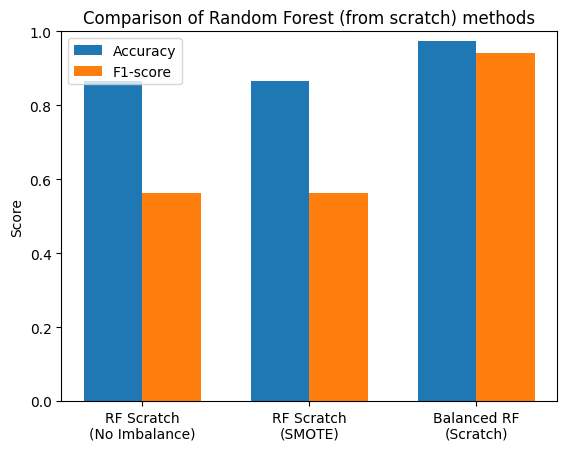

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Méthodes
methods = [
    "RF Scratch\n(No Imbalance)",
    "RF Scratch\n(SMOTE)",
    "Balanced RF\n(Scratch)"
]

# Scores
accuracy = [
    0.8657800261096605,
    0.8657800261096605,
    0.9744381760537113
]

f1_score = [
    0.5631804559766321,
    0.5631804559766321,
    0.9408878945524138
]

x = np.arange(len(methods))
width = 0.35

plt.figure()
plt.bar(x - width/2, accuracy, width, label="Accuracy")
plt.bar(x + width/2, f1_score, width, label="F1-score")

plt.xticks(x, methods)
plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("Comparison of Random Forest (from scratch) methods")
plt.legend()

plt.show()


### Random Forest avec SKLEARN

### classical Random Forest

#### Sans imbalance

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Créer le Random Forest
rf = RandomForestClassifier(
    n_estimators=100,       # nombre d'arbres
    max_depth=None,         # profondeur maximale
    random_state=42,
    n_jobs=-1
)

# Entraîner sur le train set original
rf.fit(X_train, y_train)

# Prédire sur le test set
y_pred_rf = rf.predict(X_test)

# Évaluation
print("Random Forest (train set original, sans rééquilibrage)")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest (train set original, sans rééquilibrage)
Accuracy: 0.9893579820962327
F1 Score: 0.9743070212466582
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     67994
           1       0.98      0.97      0.97     17798

    accuracy                           0.99     85792
   macro avg       0.98      0.98      0.98     85792
weighted avg       0.99      0.99      0.99     85792



In [ ]:
# Sauvegarde des prédictions RF Original
rf_orig_pred_path = "data/processed/y_pred_rf_original.pkl"
with open(rf_orig_pred_path, "wb") as f:
    pickle.dump(y_pred_rf, f)
print(f"y_pred RF Original saved at {rf_orig_pred_path}")


y_pred RF Original saved at data/processed/y_pred_rf_original.pkl


#### Avec SMOTE Oversampling

In [ ]:
# Créer le Random Forest
rf_smote = RandomForestClassifier(
    n_estimators=100,       # nombre d'arbres
    max_depth=None,         # profondeur maximale
    random_state=42,
    n_jobs=-1
)

# Entraîner le modèle sur l'ensemble SMOTE
rf_smote.fit(X_train_res, y_train_res)

# Prédire sur le test set (non rééchantillonné)
y_pred_rf_smote = rf_smote.predict(X_test)

# Évaluation
print("Random Forest Classique (SMOTE Oversampling)")
print("Accuracy:", accuracy_score(y_test, y_pred_rf_smote))
print("F1 Score:", f1_score(y_test, y_pred_rf_smote))
print(classification_report(y_test, y_pred_rf_smote))

c:\Users\HOME\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


Random Forest Classique (SMOTE Oversampling)
Accuracy: 0.9886236478925774
F1 Score: 0.9725888895130034
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     67994
           1       0.97      0.97      0.97     17798

    accuracy                           0.99     85792
   macro avg       0.98      0.98      0.98     85792
weighted avg       0.99      0.99      0.99     85792



In [ ]:
# Sauvegarde des prédictions RF SMOTE
rf_smote_pred_path = "data/processed/y_pred_rf_smote.pkl"
with open(rf_smote_pred_path, "wb") as f:
    pickle.dump(y_pred_rf_smote, f)
print(f"y_pred RF SMOTE saved at {rf_smote_pred_path}")


y_pred RF SMOTE saved at data/processed/y_pred_rf_smote.pkl


### Balanced Random Forest

"pas besoin de imbalance ici on utilise directement le dataset originale car
on a class_weight='balanced'  # pondération automatique des classes "

In [ ]:

rf_balanced = RandomForestClassifier(
    n_estimators=100,        # nombre d'arbres
    max_depth=None,          # profondeur maximale
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'  # pondération automatique des classes
)

# Entraîner sur le train set original
rf_balanced.fit(X_train, y_train)

# Prédire sur le test set
y_pred_rf_balanced = rf_balanced.predict(X_test)

# Évaluation
print("Balanced Random Forest (train set original, class_weight='balanced')")
print("Accuracy:", accuracy_score(y_test, y_pred_rf_balanced))
print("F1 Score:", f1_score(y_test, y_pred_rf_balanced))
print(classification_report(y_test, y_pred_rf_balanced))


Balanced Random Forest (train set original, class_weight='balanced')
Accuracy: 0.9892763894069377
F1 Score: 0.9741151313938439
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     67994
           1       0.98      0.97      0.97     17798

    accuracy                           0.99     85792
   macro avg       0.98      0.98      0.98     85792
weighted avg       0.99      0.99      0.99     85792



In [ ]:
# Sauvegarde des prédictions RF Balanced
rf_balanced_pred_path = "data/processed/y_pred_rf_balanced.pkl"
with open(rf_balanced_pred_path, "wb") as f:
    pickle.dump(y_pred_rf_balanced, f)
print(f"y_pred RF Balanced saved at {rf_balanced_pred_path}")


y_pred RF Balanced saved at data/processed/y_pred_rf_balanced.pkl


### Comparaison entre les trois

Comparaison des performances Random Forest :
                  Method  Accuracy  F1 Score  Precision    Recall
0  RF Classique Original  0.989358  0.974307   0.975982  0.972637
1     RF Classique SMOTE  0.988624  0.972589   0.972316  0.972862
2            RF Balanced  0.989276  0.974115   0.975597  0.972637


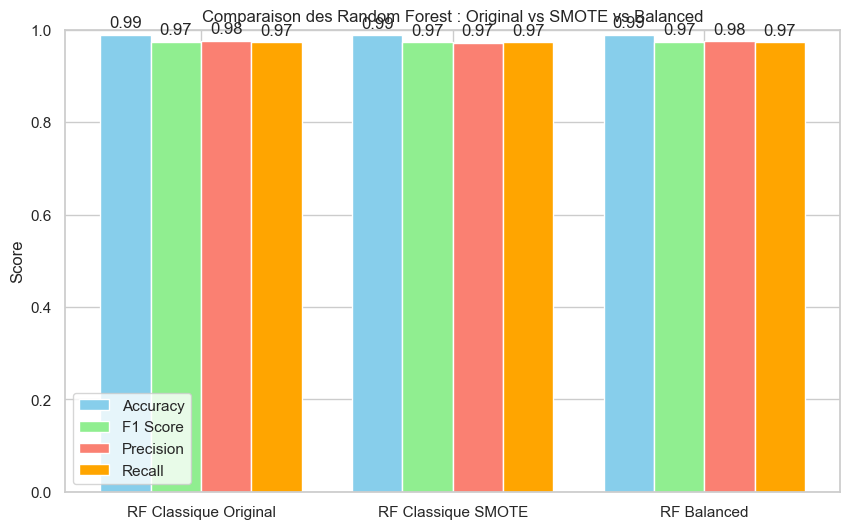

In [ ]:

# Calcul des métriques
methods = ['RF Classique Original', 'RF Classique SMOTE', 'RF Balanced']

accuracy_scores = [
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_rf_smote),
    accuracy_score(y_test, y_pred_rf_balanced)
]

f1_scores = [
    f1_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_rf_smote),
    f1_score(y_test, y_pred_rf_balanced)
]

precision_scores = [
    precision_score(y_test, y_pred_rf),
    precision_score(y_test, y_pred_rf_smote),
    precision_score(y_test, y_pred_rf_balanced)
]

recall_scores = [
    recall_score(y_test, y_pred_rf),
    recall_score(y_test, y_pred_rf_smote),
    recall_score(y_test, y_pred_rf_balanced)
]

# DataFrame pour affichage
comparison_df = pd.DataFrame({
    'Method': methods,
    'Accuracy': accuracy_scores,
    'F1 Score': f1_scores,
    'Precision': precision_scores,
    'Recall': recall_scores
})

print("Comparaison des performances Random Forest :")
print(comparison_df)


# Visualisation graphique

x = range(len(methods))
width = 0.2

fig, ax = plt.subplots(figsize=(10,6))

rects1 = ax.bar([i - width*1.5 for i in x], accuracy_scores, width, label='Accuracy', color='skyblue')
rects2 = ax.bar([i - width/2 for i in x], f1_scores, width, label='F1 Score', color='lightgreen')
rects3 = ax.bar([i + width/2 for i in x], precision_scores, width, label='Precision', color='salmon')
rects4 = ax.bar([i + width*1.5 for i in x], recall_scores, width, label='Recall', color='orange')

ax.set_ylabel('Score')
ax.set_ylim(0,1)
ax.set_title('Comparaison des Random Forest : Original vs SMOTE vs Balanced')
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.legend()

# Afficher les valeurs sur les barres
for rects in [rects1, rects2, rects3, rects4]:
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width()/2, height),
                    xytext=(0,3),
                    textcoords="offset points",
                    ha='center', va='bottom')

plt.show()


### comparaison 

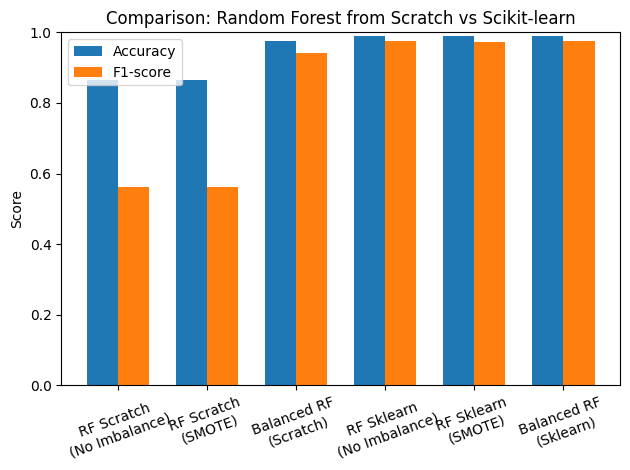

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Méthodes comparées
methods = [
    "RF Scratch\n(No Imbalance)",
    "RF Scratch\n(SMOTE)",
    "Balanced RF\n(Scratch)",
    "RF Sklearn\n(No Imbalance)",
    "RF Sklearn\n(SMOTE)",
    "Balanced RF\n(Sklearn)"
]

# Accuracy
accuracy = [
    0.8657800261096605,   # Scratch no imbalance
    0.8657800261096605,   # Scratch SMOTE
    0.9744381760537113,   # Balanced Scratch
    0.9893579820962327,   # Sklearn no imbalance
    0.9886236478925774,   # Sklearn SMOTE
    0.9892763894069377    # Balanced Sklearn
]

# F1-score
f1_score = [
    0.5631804559766321,   # Scratch no imbalance
    0.5631804559766321,   # Scratch SMOTE
    0.9408878945524138,   # Balanced Scratch
    0.9743070212466582,   # Sklearn no imbalance
    0.9725888895130034,   # Sklearn SMOTE
    0.9741151313938439    # Balanced Sklearn
]

x = np.arange(len(methods))
width = 0.35

plt.figure()
plt.bar(x - width/2, accuracy, width, label="Accuracy")
plt.bar(x + width/2, f1_score, width, label="F1-score")

plt.xticks(x, methods, rotation=20)
plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("Comparison: Random Forest from Scratch vs Scikit-learn")
plt.legend()

plt.tight_layout()
plt.show()


## Comparaison entre les 3 modeles knnn decisiontree et random forest

Comparaison globale des modèles :
                 Model  Accuracy  F1 Score  Precision    Recall
0            KNN SMOTE  0.975930  0.943383   0.921232  0.966625
1              KNN RUS  0.957222  0.904203   0.844384  0.973143
2  Decision Tree SMOTE  0.909607  0.812196   0.713726  0.942185
3    Decision Tree RUS  0.910062  0.812691   0.715464  0.940499
4          RF Original  0.989358  0.974307   0.975982  0.972637
5             RF SMOTE  0.988624  0.972589   0.972316  0.972862
6          RF Balanced  0.989276  0.974115   0.975597  0.972637


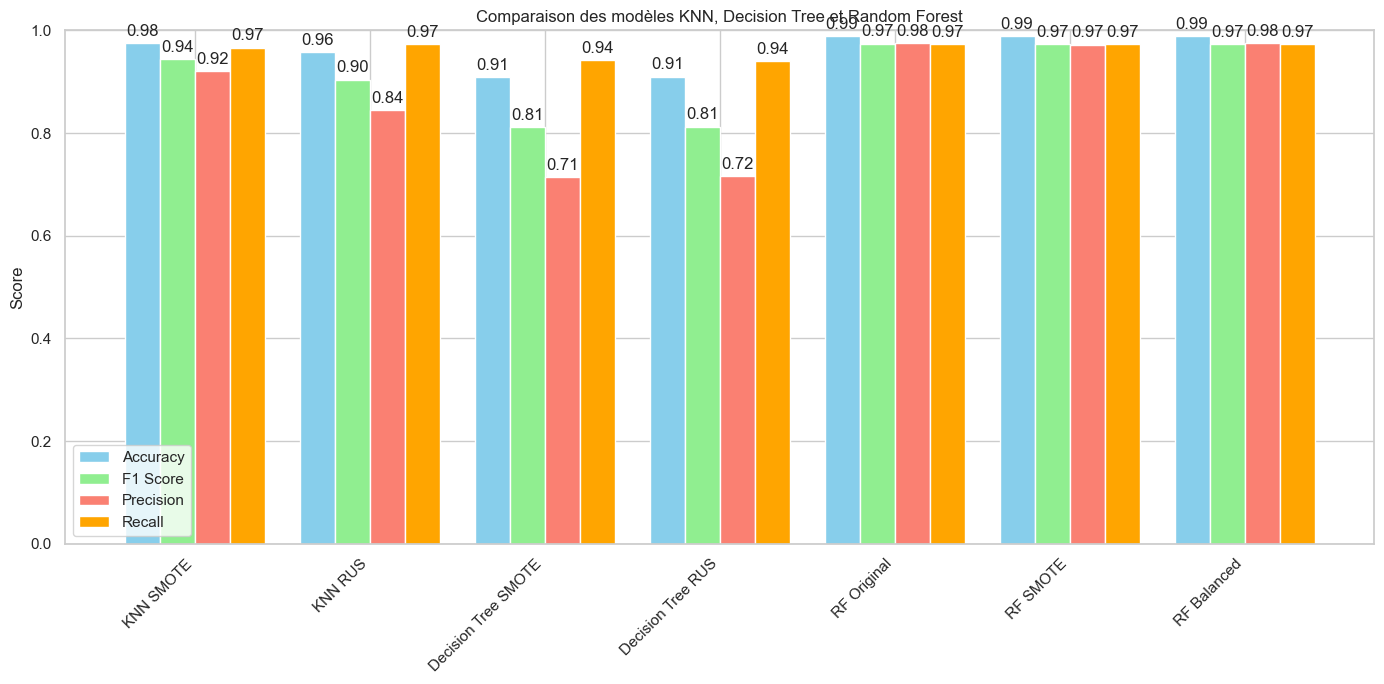

In [ ]:

# calculer les scores pour chaque modèle

methods = [
    'KNN SMOTE', 'KNN RUS',
    'Decision Tree SMOTE', 'Decision Tree RUS',
    'RF Original', 'RF SMOTE', 'RF Balanced'
]

accuracy_scores = [
    accuracy_score(y_test, y_pred),       # KNN SMOTE
    accuracy_score(y_test, y_pred_rus),  # KNN RUS
    accuracy_score(y_test, y_pred_dct),  # DT SMOTE
    accuracy_score(y_test, y_pred_dct2), # DT RUS
    accuracy_score(y_test, y_pred_rf),       # RF Original
    accuracy_score(y_test, y_pred_rf_smote), # RF SMOTE
    accuracy_score(y_test, y_pred_rf_balanced) # RF Balanced
]

f1_scores = [
    f1_score(y_test, y_pred),
    f1_score(y_test, y_pred_rus),
    f1_score(y_test, y_pred_dct),
    f1_score(y_test, y_pred_dct2),
    f1_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_rf_smote),
    f1_score(y_test, y_pred_rf_balanced)
]

precision_scores = [
    precision_score(y_test, y_pred),
    precision_score(y_test, y_pred_rus),
    precision_score(y_test, y_pred_dct),
    precision_score(y_test, y_pred_dct2),
    precision_score(y_test, y_pred_rf),
    precision_score(y_test, y_pred_rf_smote),
    precision_score(y_test, y_pred_rf_balanced)
]

recall_scores = [
    recall_score(y_test, y_pred),
    recall_score(y_test, y_pred_rus),
    recall_score(y_test, y_pred_dct),
    recall_score(y_test, y_pred_dct2),
    recall_score(y_test, y_pred_rf),
    recall_score(y_test, y_pred_rf_smote),
    recall_score(y_test, y_pred_rf_balanced)
]

# créer le DataFrame comparatif

comparison_df = pd.DataFrame({
    'Model': methods,
    'Accuracy': accuracy_scores,
    'F1 Score': f1_scores,
    'Precision': precision_scores,
    'Recall': recall_scores
})

print("Comparaison globale des modèles :")
print(comparison_df)

# visualisation graphique

x = np.arange(len(methods))
width = 0.2

fig, ax = plt.subplots(figsize=(14,7))

rects1 = ax.bar(x - 1.5*width, accuracy_scores, width, label='Accuracy', color='skyblue')
rects2 = ax.bar(x - 0.5*width, f1_scores, width, label='F1 Score', color='lightgreen')
rects3 = ax.bar(x + 0.5*width, precision_scores, width, label='Precision', color='salmon')
rects4 = ax.bar(x + 1.5*width, recall_scores, width, label='Recall', color='orange')

ax.set_ylabel('Score')
ax.set_ylim(0,1)
ax.set_title('Comparaison des modèles KNN, Decision Tree et Random Forest')
ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=45, ha='right')
ax.legend()

# Ajouter les valeurs sur les barres
for rects in [rects1, rects2, rects3, rects4]:
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width()/2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

plt.tight_layout()
plt.show()


In [ ]:
#saving

In [ ]:
# Folder path
save_dir = "data/processed"
os.makedirs(save_dir, exist_ok=True)  # Create folder if it doesn't exist

# File path
save_path = os.path.join(save_dir, "df_encoded.pkl")

# Save silently
with open(save_path, "wb") as f:
    pickle.dump(df_encoded, f);

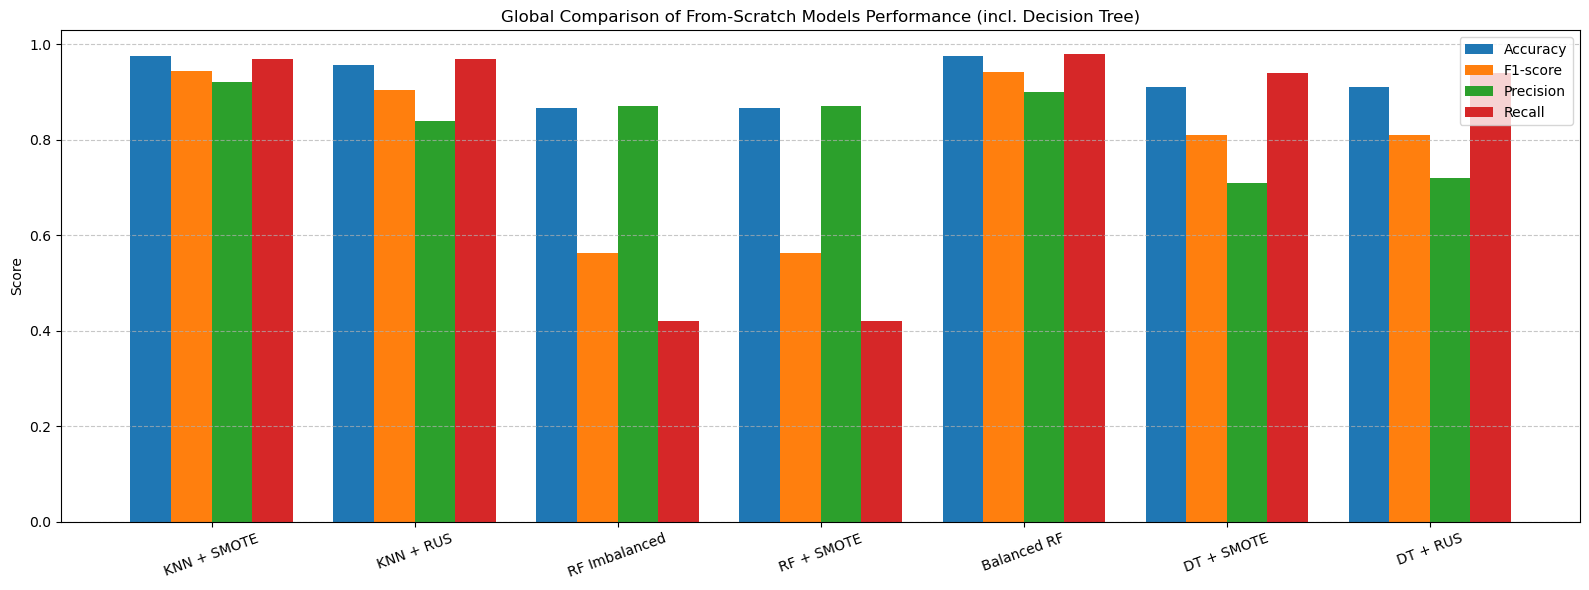

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Models and metrics (from scratch results + Decision Tree)
models = [
    "KNN + SMOTE",
    "KNN + RUS",
    "RF Imbalanced",
    "RF + SMOTE",
    "Balanced RF",
    "DT + SMOTE",
    "DT + RUS"
]

accuracy = [
    0.9759,
    0.9569,
    0.8658,
    0.8658,
    0.9744,
    0.91,
    0.91
]

f1_score = [
    0.9435,
    0.9036,
    0.5632,
    0.5632,
    0.9409,
    0.81,
    0.81
]

recall = [
    0.97,
    0.97,
    0.42,
    0.42,
    0.98,
    0.94,
    0.94
]

precision = [
    0.92,
    0.84,
    0.87,
    0.87,
    0.90,
    0.71,
    0.72
]

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(16, 6))

plt.bar(x - 1.5*width, accuracy, width, label="Accuracy")
plt.bar(x - 0.5*width, f1_score, width, label="F1-score")
plt.bar(x + 0.5*width, precision, width, label="Precision")
plt.bar(x + 1.5*width, recall, width, label="Recall")

plt.xticks(x, models, rotation=20)
plt.ylabel("Score")
plt.title("Global Comparison of From-Scratch Models Performance (incl. Decision Tree)")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()


## DBSCAN

In [ ]:
X_train_np = X_train.to_numpy()
y_train_np = y_train.to_numpy()


In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from collections import Counter

# Échantillon pour silhouette
sample_size = min(10000, len(X_train_np))
sample_indices = np.random.choice(len(X_train_np), sample_size, replace=False)
X_sample = X_train_np[sample_indices]

In [ ]:
eps_values = [0.3, 0.5, 0.7]
min_samples_values = [5, 10, 15]
metrics = ['euclidean', 'manhattan']

best_score = -1
best_params = None

In [ ]:
for metric in metrics:
    for eps in eps_values:
        for min_samples in min_samples_values:
            dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric=metric)
            labels_sample = dbscan.fit_predict(X_sample)

            # Nombre de clusters et pourcentage de bruit
            n_clusters = len(set(labels_sample)) - (1 if -1 in labels_sample else 0)
            noise_pct = np.sum(labels_sample == -1) / len(labels_sample)

            print(f"metric={metric}, eps={eps}, min_samples={min_samples}, clusters={n_clusters}, noise={noise_pct:.2f}")


            # le nombre de clusters > 1 et le pourcentage de bruit le plus faible
            if n_clusters > 1 and (best_score == -1 or noise_pct < best_score):
                best_score = noise_pct  # on garde le plus faible bruit
                best_params = {'metric': metric, 'eps': eps, 'min_samples': min_samples}

print("\nMeilleurs paramètres DBSCAN:", best_params)


metric=euclidean, eps=0.7, min_samples=10, clusters=44, noise=0.94
metric=euclidean, eps=0.7, min_samples=15, clusters=12, noise=0.98
metric=euclidean, eps=0.7, min_samples=20, clusters=5, noise=0.99
metric=euclidean, eps=0.7999999999999999, min_samples=10, clusters=45, noise=0.94
metric=euclidean, eps=0.7999999999999999, min_samples=15, clusters=12, noise=0.98
metric=euclidean, eps=0.7999999999999999, min_samples=20, clusters=5, noise=0.99
metric=euclidean, eps=0.8999999999999999, min_samples=10, clusters=45, noise=0.94
metric=euclidean, eps=0.8999999999999999, min_samples=15, clusters=13, noise=0.97
metric=euclidean, eps=0.8999999999999999, min_samples=20, clusters=6, noise=0.98
metric=euclidean, eps=0.9999999999999999, min_samples=10, clusters=48, noise=0.92
metric=euclidean, eps=0.9999999999999999, min_samples=15, clusters=14, noise=0.97
metric=euclidean, eps=0.9999999999999999, min_samples=20, clusters=5, noise=0.98
metric=euclidean, eps=1.0999999999999999, min_samples=10, cluster

In [ ]:
dbscan_final = DBSCAN(
    eps=best_params['eps'],
    min_samples=best_params['min_samples'],
    metric=best_params['metric']
)
final_labels = dbscan_final.fit_predict(X_train_np)

In [ ]:
cluster_to_class = {}
for cluster in set(final_labels):
    if cluster == -1:
        continue  # ignorer le bruit
    mask = final_labels == cluster
    majority_class = Counter(y_train_np[mask]).most_common(1)[0][0]
    cluster_to_class[cluster] = majority_class


In [ ]:
centroids = {c: X_train_np[final_labels == c].mean(axis=0) for c in cluster_to_class}


In [ ]:

X_test_np = X_test.to_numpy()
y_test_np = y_test.to_numpy()


In [ ]:
def dbscan_predict_memory_safe(X, centroids, cluster_to_class):
    preds = []
    for x in X:
        # calculer distance à chaque centroid
        min_dist = float('inf')
        closest_cluster = None
        for c, centroid in centroids.items():
            dist = np.linalg.norm(x - centroid)
            if dist < min_dist:
                min_dist = dist
                closest_cluster = c
        preds.append(cluster_to_class[closest_cluster])
    return np.array(preds)

# Utilisation
y_pred_dbscan = dbscan_predict_memory_safe(X_test_np, centroids, cluster_to_class)


In [ ]:
# Utilisation
y_pred_dbscan = dbscan_predict_memory_safe(X_test_np, centroids, cluster_to_class)

In [ ]:
dbscan_pred_path = "data/processed/y_pred_dbscan.pkl"
with open(dbscan_pred_path, "wb") as f:
    pickle.dump(y_pred_dbscan, f)

print(f"y_pred DBSCAN saved at {dbscan_pred_path}")


y_pred DBSCAN saved at data/processed/y_pred_dbscan.pkl


In [ ]:
labels = dbscan_final.fit_predict(X_train_np)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print("Nombre de clusters :", n_clusters)


Nombre de clusters : 4619


In [ ]:
# Taux de bruit (entre 0 et 1)
noise_ratio = np.mean(labels == -1)

# Pourcentage de bruit
noise_percentage = noise_ratio * 100

print(f"Taux de bruit : {noise_ratio:.4f}")
print(f"Pourcentage de bruit : {noise_percentage:.2f} %")


Taux de bruit : 0.4956
Pourcentage de bruit : 49.56 %


In [ ]:
from collections import Counter

cluster_sizes = Counter(labels)
cluster_sizes.pop(-1, None)  # enlever bruit

mean_cluster_size = np.mean(list(cluster_sizes.values()))
print("Taille moyenne des clusters :", mean_cluster_size)


Taille moyenne des clusters : 37.47759255250054


In [ ]:
useful_points = np.sum(labels != -1)
cluster_density_ratio = n_clusters / useful_points

print("Ratio clusters / points utiles :", cluster_density_ratio)


Ratio clusters / points utiles : 0.026682610378432087


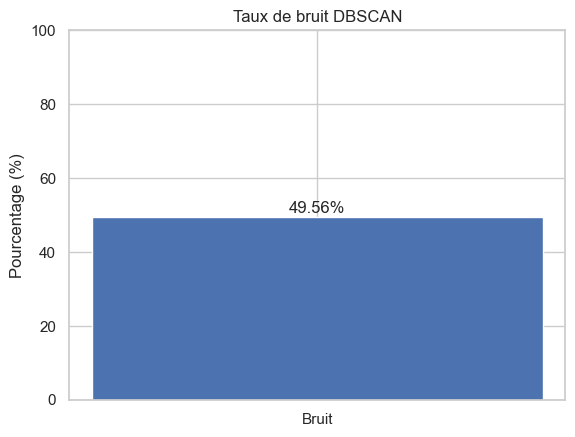

In [ ]:
plt.bar(["Bruit"], [noise_percentage])
plt.ylabel("Pourcentage (%)")
plt.title("Taux de bruit DBSCAN")

plt.text(0, noise_percentage + 1, f"{noise_percentage:.2f}%", ha='center')
plt.ylim(0, 100)
plt.show()


## From scratch

Dans le TP :

Pour DBSCAN sklearn, on évalue les clusters et le bruit sur le training set.

La “prédiction” sur X_test que j'ai faite faite avec les centroids est une méthode approximative, mais ce n’est pas du DBSCAN pur.  (LI KHDATLI 1H PEUT NKHALOHA EN PLUS 7A9 UNE HEURE )

In [ ]:
import numpy as np
from collections import deque

class DBSCANScratch:
    def __init__(self, eps=0.5, min_samples=5):
        self.eps = eps
        self.min_samples = min_samples
        self.labels_ = None

    def fit(self, X):
        n_samples = X.shape[0]
        self.labels_ = -1 * np.ones(n_samples, dtype=int)  # Tout initialement bruit
        cluster_id = 0
        visited = np.zeros(n_samples, dtype=bool)

        for i in range(n_samples):
            if visited[i]:
                continue
            visited[i] = True
            neighbors = self.region_query(X, i)

            if len(neighbors) < self.min_samples:
                # bruit, label reste -1
                continue
            # Sinon, on a un nouveau cluster
            self.expand_cluster(X, i, neighbors, cluster_id, visited)
            cluster_id += 1
        return self

    def region_query(self, X, idx):
        """Retourne les indices des points dans le rayon eps autour de X[idx]"""
        point = X[idx]
        # Calcul des distances euclidiennes
        distances = np.linalg.norm(X - point, axis=1)
        neighbors = np.where(distances <= self.eps)[0]
        return neighbors.tolist()

    def expand_cluster(self, X, idx, neighbors, cluster_id, visited):
        self.labels_[idx] = cluster_id
        queue = deque(neighbors)
        while queue:
            j = queue.popleft()
            if not visited[j]:
                visited[j] = True
                j_neighbors = self.region_query(X, j)
                if len(j_neighbors) >= self.min_samples:
                    queue.extend(j_neighbors)
            if self.labels_[j] == -1:
                self.labels_[j] = cluster_id

# Exemple d'utilisation
db_scratch = DBSCANScratch(eps=0.7, min_samples=10)
db_scratch.fit(X_train_np)
labels_scratch = db_scratch.labels_

# Nombre de clusters
n_clusters_scratch = len(set(labels_scratch)) - (1 if -1 in labels_scratch else 0)
noise_ratio_scratch = np.mean(labels_scratch == -1)

print("DBSCAN from scratch")
print("Nombre de clusters :", n_clusters_scratch)
print(f"Taux de bruit : {noise_ratio_scratch:.4f}")


In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Pour sklearn DBSCAN
labels_sklearn = dbscan_final.fit_predict(X_train_np)

print("Silhouette (sklearn) :", silhouette_score(X_train_np, labels_sklearn))
print("Silhouette (scratch) :", silhouette_score(X_train_np, labels_scratch))

print("Davies-Bouldin (sklearn) :", davies_bouldin_score(X_train_np, labels_sklearn))
print("Davies-Bouldin (scratch) :", davies_bouldin_score(X_train_np, labels_scratch))

print("Calinski-Harabasz (sklearn) :", calinski_harabasz_score(X_train_np, labels_sklearn))
print("Calinski-Harabasz (scratch) :", calinski_harabasz_score(X_train_np, labels_scratch))


## K-MEANS

Features only (no target)

In [ ]:
X_kmeans = df_encoded.copy()

Keep numeric columns only

In [ ]:
numeric_cols = X_kmeans.select_dtypes(
    include=['float64', 'float32', 'int64']
).columns

X_kmeans = X_kmeans[numeric_cols]

Scale using the FULL dataset

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_kmeans_scaled = scaler.fit_transform(X_kmeans)

In [ ]:
X_np = X_kmeans_scaled  # already NumPy after scaling


CH computation function for k hypertuning

In [ ]:
from sklearn.metrics import calinski_harabasz_score
from sklearn.cluster import KMeans
def compute_CH(X, labels):
    """
    Compute Calinski-Harabasz score for given clustering.
    """
    return calinski_harabasz_score(X, labels)


In [ ]:
K_values = range(2, 11)  # try K = 2 → 10
CH_scores = []

# Optional: sample subset for speed
sample_size = 50000
if X_np.shape[0] > sample_size:
    idx = np.random.choice(X_np.shape[0], size=sample_size, replace=False)
    X_sample = X_np[idx]
else:
    X_sample = X_np

for K in K_values:
    print(f"Testing K={K}...")

    kmeans = KMeans(
        n_clusters=K,
        init='k-means++',
        n_init=10,         # number of random restarts
        max_iter=100,
        random_state=42
    )

    labels = kmeans.fit_predict(X_sample)
    ch = calinski_harabasz_score(X_sample, labels)
    CH_scores.append(ch)
    print(f"  CH score = {ch:.2f}")


Testing K=2...
  CH score = 10896.02
Testing K=3...
  CH score = 8339.54
Testing K=4...
  CH score = 7212.03
Testing K=5...
  CH score = 6646.62
Testing K=6...
  CH score = 6203.50
Testing K=7...
  CH score = 5885.70
Testing K=8...
  CH score = 5602.67
Testing K=9...
  CH score = 4967.09
Testing K=10...
  CH score = 4937.72


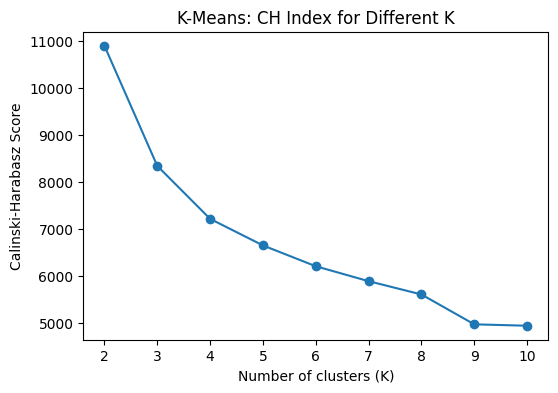

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(K_values, CH_scores, marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("Calinski-Harabasz Score")
plt.title("K-Means: CH Index for Different K")
plt.show()

elbow method:

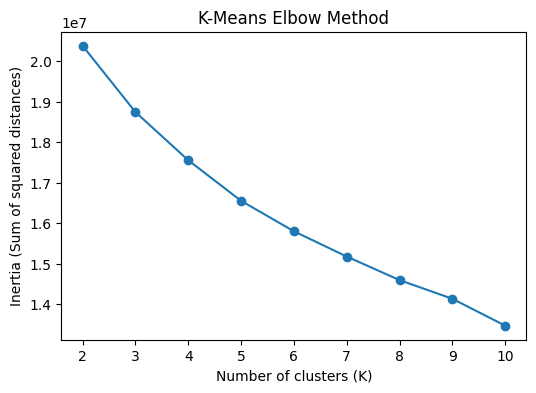

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertia_values = []

for K in range(2, 11):
    kmeans = KMeans(
        n_clusters=K,
        init='k-means++',
        n_init=10,
        max_iter=100,
        random_state=42
    )
    kmeans.fit(X_np)
    inertia_values.append(kmeans.inertia_)  # sum of squared distances to centroids

# Plot
plt.figure(figsize=(6,4))
plt.plot(range(2, 11), inertia_values, marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia (Sum of squared distances)")
plt.title("K-Means Elbow Method")
plt.show()


In [ ]:
print(inertia_values)


[20381539.608856417, 18745372.787044637, 17553770.43757431, 16551566.242143184, 15799019.204253323, 15175488.029536914, 14593195.945061086, 14131863.047581237, 13467100.246996384]


```To determine the optimal number of clusters (K) for our K-Means clustering, we used two methods: the Calinski–Harabasz (CH) index and the Elbow method. The CH index measures the ratio of between-cluster variance to within-cluster variance, with higher values indicating more compact and well-separated clusters. We tested K values from 2 to 10 and found that the CH index was maximized at K=2, suggesting that the dataset naturally splits into two main clusters. We also computed the inertia (sum of squared distances to centroids) for the same range of K values to apply the Elbow method. The largest drop in inertia occurs at K=2, with subsequent reductions becoming progressively smaller, which visually supports the choice of K=2. Based on these results, we selected K=2 as the optimal number of clusters, and fitted K-Means to the full dataset to assign cluster labels. This approach ensures that the clusters are compact, well-separated, and interpretable in relation to the dataset’s features.```

checking for k=2

In [ ]:
from sklearn.cluster import KMeans

# Define number of clusters
K = 2

# Initialize KMeans
kmeans = KMeans(
    n_clusters=K,        # number of clusters
    init='k-means++',    # smart initialization
    n_init=10,           # number of random restarts
    max_iter=100,        # max iterations per run
    random_state=42      # reproducibility
)

# Fit KMeans and get cluster labels
labels = kmeans.fit_predict(X_np)

# Add cluster labels to your dataframe
df_all['cluster'] = labels

# Optional: check cluster sizes
print(df_all['cluster'].value_counts())

# Optional: check cluster feature means for interpretation
print(df_all.groupby('cluster')[numeric_cols].mean())


cluster
0    325970
1    102989
Name: count, dtype: int64
         prec_winter  prec_spring  prec_summer  prec_fall  tmax_winter  \
cluster                                                                  
0           3.205983     3.718293     0.952672   5.204357    20.481104   
1          35.352798    18.881880     6.071580  26.218031    14.938118   

         tmax_spring  tmax_summer  tmax_fall  tmin_winter  tmin_spring  ...  \
cluster                                                                 ...   
0          31.380590    42.694790  32.099327     6.200634    16.178043  ...   
1          22.664061    34.523827  25.013081     4.796099    10.391465  ...   

         LCCCode_21497-15045  LCCCode_21499-121340  LCCCode_21518  \
cluster                                                             
0                   0.000000              0.000000       0.000006   
1                   0.000068              0.001495       0.007078   

         LCCCode_6001  LCCCode_6004  LCCCode_6020  

```
Cluster 0: Hot, dry, sandy, most of the data (~3/4 of points) → “typical area

Cluster 1: Cooler, wetter, clay-heavy soils (~1/4 of points) → “extreme / higher-risk areas```


```Although the Calinski–Harabasz index is maximized at K=2, we chose K=4 for clustering to capture more nuanced environmental patterns in the dataset. K=2 separates the dataset into broad ‘typical’ and ‘extreme’ regions, but our large dataset contains subtle variations in precipitation, temperature, and soil characteristics that are important for practical interpretation. K=4 allows us to distinguish these variations while keeping cluster sizes reasonable, providing actionable insights for environmental analysis and fire risk assessment.```

In [ ]:
from sklearn.cluster import KMeans
import pandas as pd

# ------------------------------
# 1. Define number of clusters
# ------------------------------
K = 4

# ------------------------------
# 2. Initialize and fit KMeans
# ------------------------------
kmeans = KMeans(
    n_clusters=K,
    init='k-means++',   # smart centroid initialization
    n_init=10,          # number of random restarts
    max_iter=100,
    random_state=42
)

# Fit KMeans and predict cluster labels
labels = kmeans.fit_predict(X_np)

# ------------------------------
# 3. Assign cluster labels to dataframe
# ------------------------------
df_all['cluster'] = labels

# ------------------------------
# 4. Inspect cluster sizes
# ------------------------------
print("Cluster sizes:")
print(df_all['cluster'].value_counts())

# ------------------------------
# 5. Inspect cluster feature means
# ------------------------------
print("\nCluster feature means:")
print(df_all.groupby('cluster')[numeric_cols].mean())

# ------------------------------
# 6. Inspect fire risk per cluster
# ------------------------------
print("\nMean fire occurrence per cluster:")
print(df_all.groupby('cluster')['fire'].mean())


Cluster sizes:
cluster
2    221871
3     90107
0     59213
1     57768
Name: count, dtype: int64

Cluster feature means:
         prec_winter  prec_spring  prec_summer  prec_fall  tmax_winter  \
cluster                                                                  
0           4.374002     4.656290     1.724033   8.166417    19.679293   
1           5.076082     4.988833     1.745524   7.573295    19.751261   
2           2.981259     3.537972     0.852852   4.546038    20.582907   
3          38.535473    20.062780     6.033989  27.377974    14.889814   

         tmax_spring  tmax_summer  tmax_fall  tmin_winter  tmin_spring  ...  \
cluster                                                                 ...   
0          30.116196    41.758175  30.823620     6.163835    15.514151  ...   
1          30.097000    41.413311  31.042717     5.957937    15.276686  ...   
2          31.636889    42.926003  32.344070     6.151383    16.290253  ...   
3          22.440634    34.223419  24.9

In [ ]:
# ------------------------------
# Settings
# ------------------------------
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

C:\Users\dell\AppData\Local\Temp\ipykernel_16736\712954804.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cluster', data=df_all, palette='Set2')


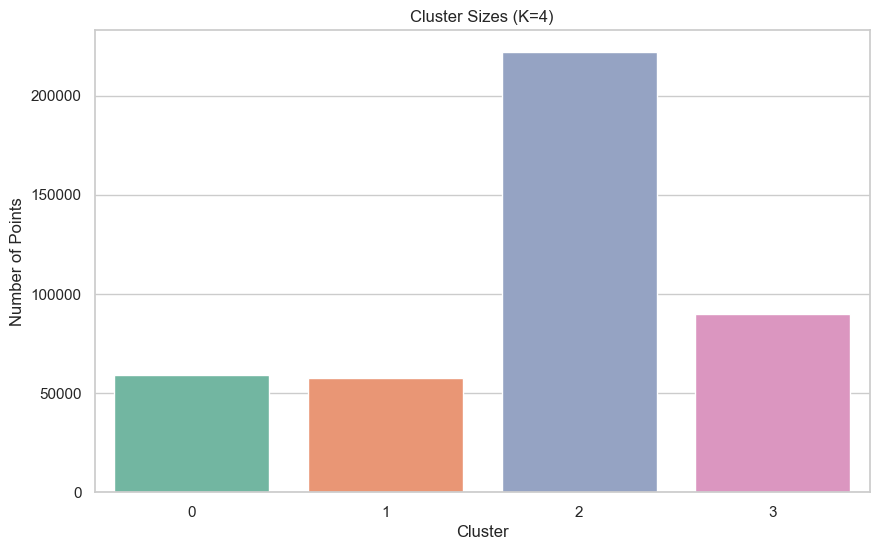

In [ ]:
# ------------------------------
# 1. Cluster sizes
# ------------------------------
plt.figure()
sns.countplot(x='cluster', data=df_all, palette='Set2')
plt.title("Cluster Sizes (K=4)")
plt.xlabel("Cluster")
plt.ylabel("Number of Points")
plt.show()


C:\Users\dell\AppData\Local\Temp\ipykernel_16736\3400940874.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fire_perc.index, y=fire_perc.values, palette='Set1')


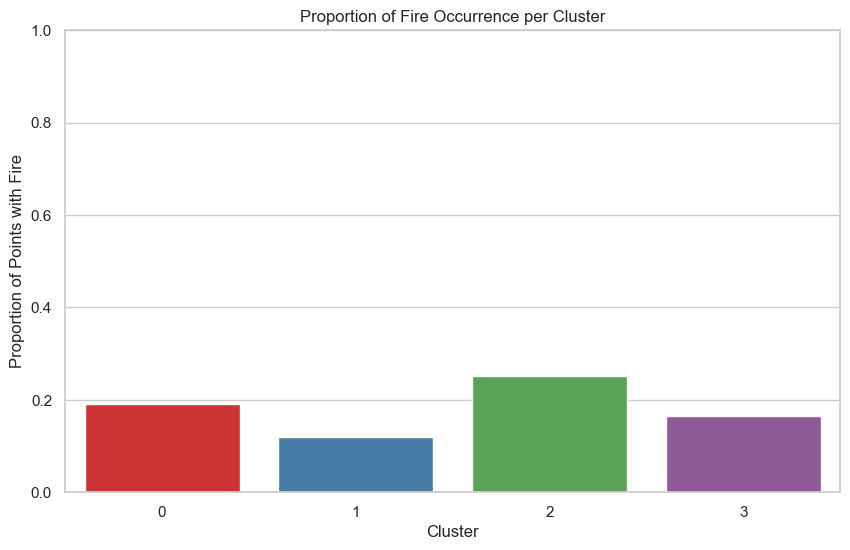

In [ ]:
# ------------------------------
# 2. Fire proportion per cluster
# ------------------------------
fire_perc = df_all.groupby('cluster')['fire'].mean()
plt.figure()
sns.barplot(x=fire_perc.index, y=fire_perc.values, palette='Set1')
plt.title("Proportion of Fire Occurrence per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Proportion of Points with Fire")
plt.ylim(0,1)
plt.show()

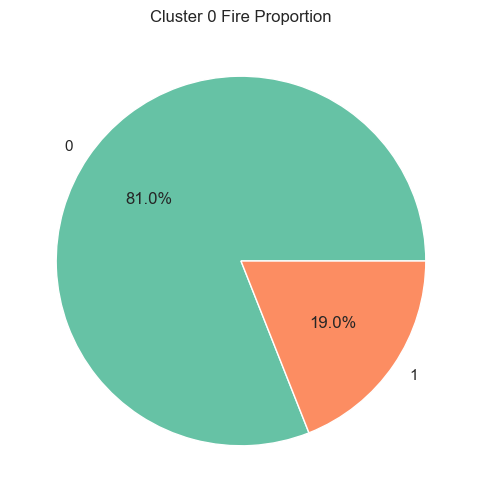

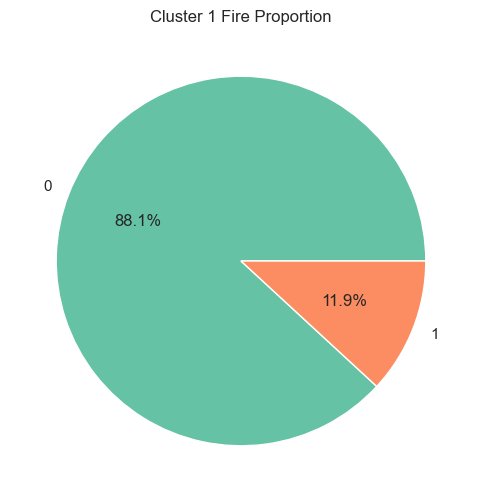

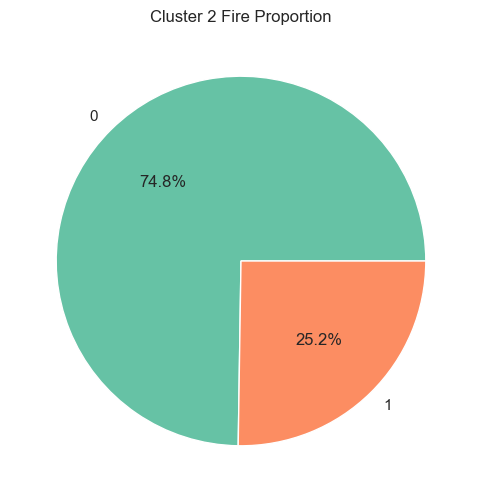

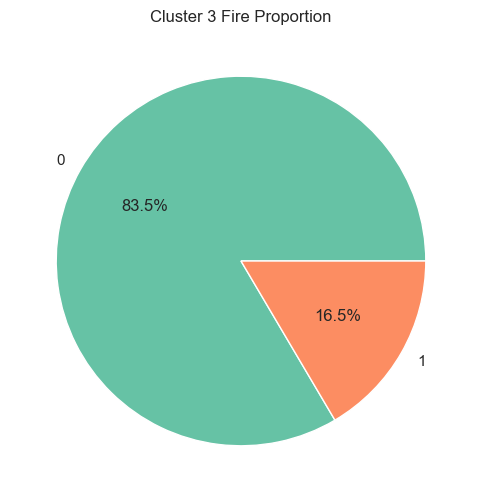

In [ ]:
# ------------------------------
# 3. Fire proportion pie charts per cluster
# ------------------------------
for c in range(4):
    cluster_fire = df_all[df_all['cluster']==c]['fire'].value_counts(normalize=True)
    plt.figure()
    cluster_fire.plot(kind='pie', autopct='%1.1f%%', colors=['#66c2a5','#fc8d62'], title=f'Cluster {c} Fire Proportion')
    plt.ylabel('')
    plt.show()

C:\Users\dell\AppData\Local\Temp\ipykernel_16736\1402903861.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y=feature, data=df_all, palette='Set3')


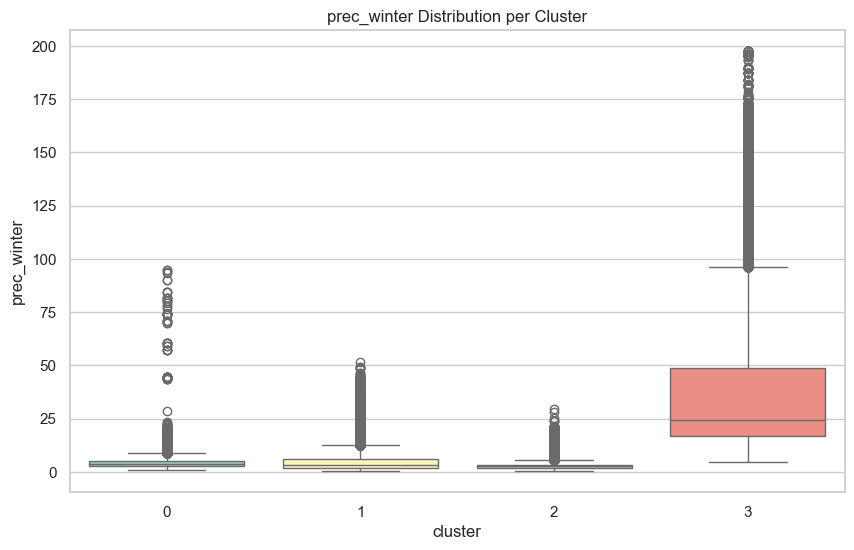

C:\Users\dell\AppData\Local\Temp\ipykernel_16736\1402903861.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y=feature, data=df_all, palette='Set3')


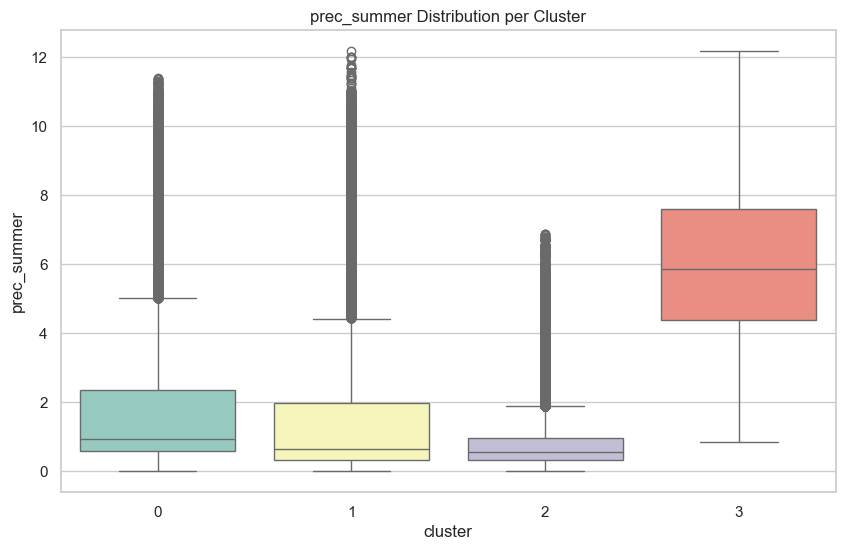

C:\Users\dell\AppData\Local\Temp\ipykernel_16736\1402903861.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y=feature, data=df_all, palette='Set3')


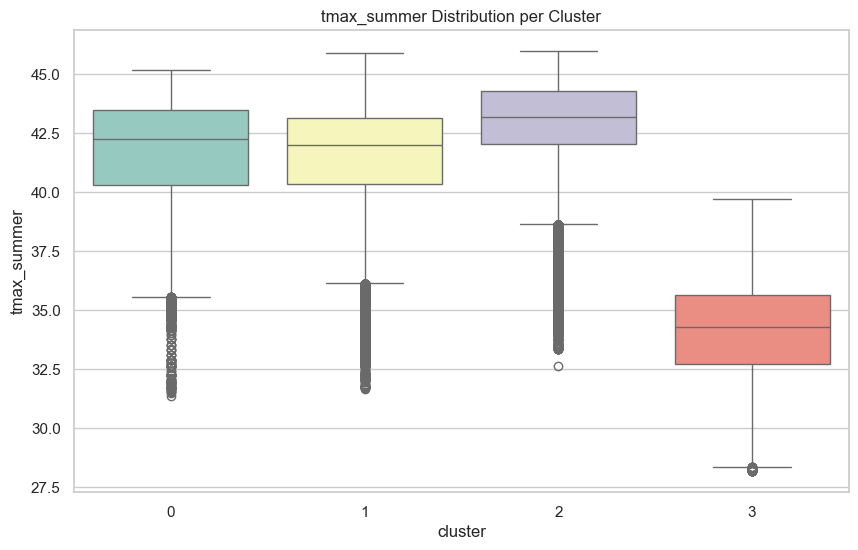

C:\Users\dell\AppData\Local\Temp\ipykernel_16736\1402903861.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y=feature, data=df_all, palette='Set3')


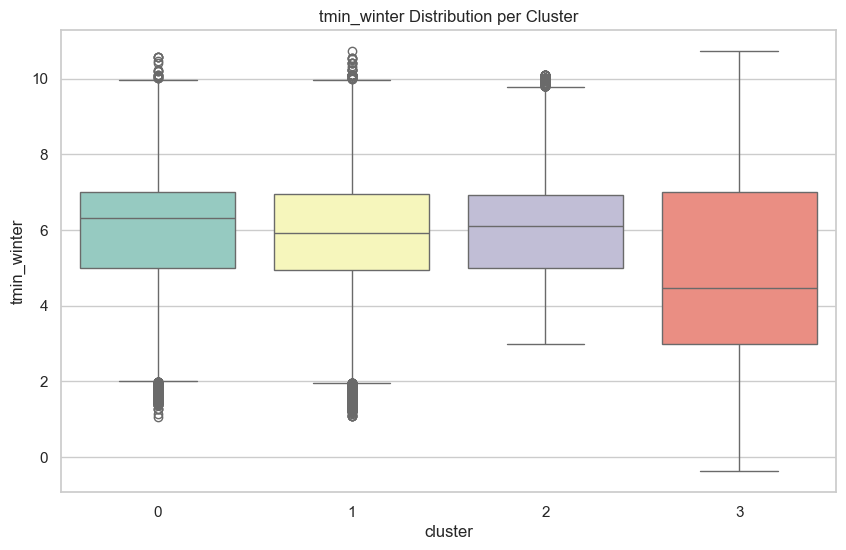

C:\Users\dell\AppData\Local\Temp\ipykernel_16736\1402903861.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y=feature, data=df_all, palette='Set3')


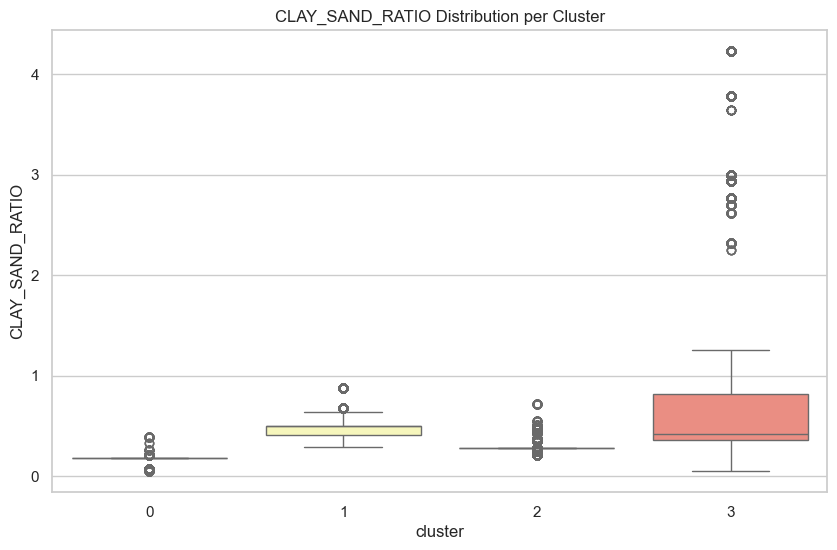

In [ ]:
key_features = ['prec_winter', 'prec_summer', 'tmax_summer', 'tmin_winter', 'CLAY_SAND_RATIO']
# ------------------------------
# 6. Boxplots of key features per cluster
# ------------------------------
for feature in key_features:
    plt.figure()
    sns.boxplot(x='cluster', y=feature, data=df_all, palette='Set3')
    plt.title(f"{feature} Distribution per Cluster")
    plt.show()

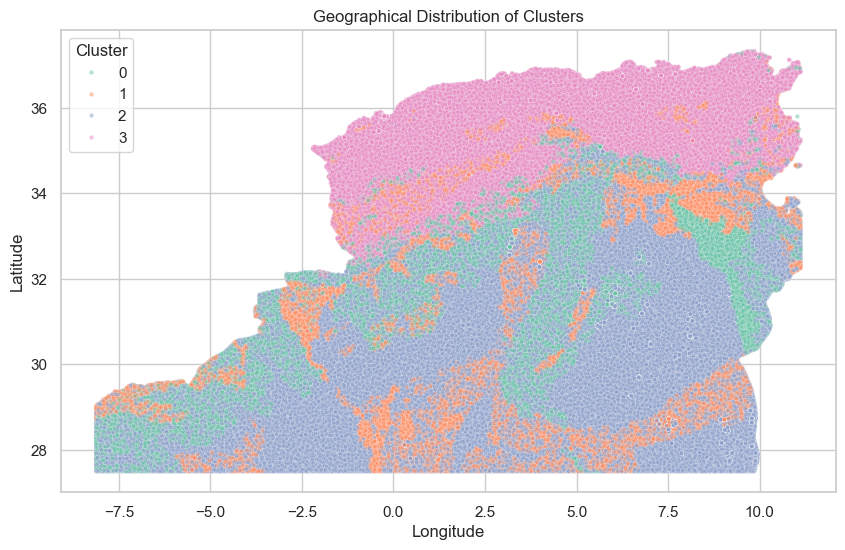

In [ ]:
# ------------------------------
# 7. Geographic plot: clusters
# ------------------------------
if 'lat' in df_all.columns and 'lon' in df_all.columns:
    plt.figure()
    sns.scatterplot(
        x='lon', y='lat',
        hue='cluster',
        data=df_all,
        palette='Set2',
        s=10,
        alpha=0.5
    )
    plt.title("Geographical Distribution of Clusters")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.legend(title='Cluster')
    plt.show()


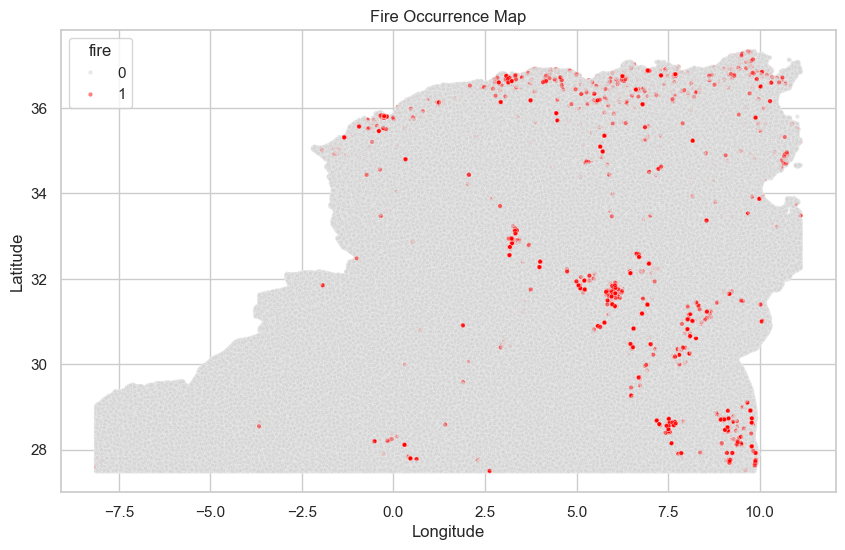

In [ ]:
# ------------------------------
# 8. Geographic plot: fire occurrence
# ------------------------------
plt.figure()
sns.scatterplot(
    x='lon', y='lat',
    hue='fire',
    data=df_all,
    palette={0:'lightgray', 1:'red'},
    s=10,
    alpha=0.5
)
plt.title("Fire Occurrence Map")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

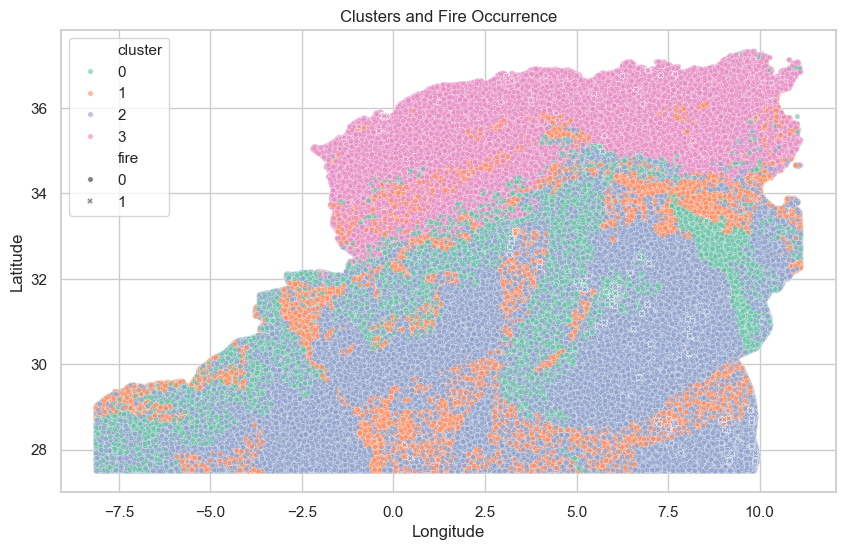

In [ ]:
# ------------------------------
# 9. Geographic plot: clusters + fire markers
# ------------------------------
plt.figure()
sns.scatterplot(
    x='lon', y='lat',
    hue='cluster',
    style='fire',
    data=df_all,
    palette='Set2',
    s=15,
    alpha=0.6
)
plt.title("Clusters and Fire Occurrence")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


K-Means from scratch

In [ ]:
class ScratchKmeans:
    """
    K-Means clustering algorithm implementation.

    Parameters:
        K (int): Number of clusters

    Attributes:
        K (int): Number of clusters
        centroids (numpy.ndarray): Array containing the centroids of each cluster

    Methods:
        __init__(self, K): Initializes the Kmeans instance with the specified number of clusters.
        initialize_centroids(self, X): Initializes the centroids for each cluster by selecting K random points from the dataset.
        assign_points_centroids(self, X): Assigns each point in the dataset to the nearest centroid.
        compute_mean(self, X, points): Computes the mean of the points assigned to each centroid.
        fit(self, X, iterations=10): Clusters the dataset using the K-Means algorithm.
    """

    def __init__(self, K):
        assert K > 0, "K should be a positive integer."
        self.K = K

    def initialize_centroids(self, X):
        assert X.shape[0] >= self.K, "Number of data points should be greater than or equal to K."

        randomized_X = np.random.permutation(X.shape[0])
        centroid_idx = randomized_X[:self.K] # get the indices for the centroids
        self.centroids = X[centroid_idx] # assign the centroids to the selected points

    def assign_points_centroids(self, X):
        """
        Assign each point in the dataset to the nearest centroid.

        Parameters:
        X (numpy.ndarray): dataset to cluster

        Returns:
        numpy.ndarray: array containing the index of the centroid for each point
        """
        X = np.expand_dims(X, axis=1) # expand dimensions to match shape of centroids
        distance = np.linalg.norm((X - self.centroids), axis=-1) # calculate Euclidean distance between each point and each centroid
        points = np.argmin(distance, axis=1) # assign each point to the closest centroid
        assert len(points) == X.shape[0], "Number of assigned points should equal the number of data points."
        return points

    def compute_mean(self, X, points):
        """
        Compute the mean of the points assigned to each centroid.

        Parameters:
        X (numpy.ndarray): dataset to cluster
        points (numpy.ndarray): array containing the index of the centroid for each point

        Returns:
        numpy.ndarray: array containing the new centroids for each cluster
        """
        centroids = np.zeros((self.K, X.shape[1])) # initialize array to store centroids
        for i in range(self.K):
            centroid_mean = X[points == i].mean(axis=0) # calculate mean of the points assigned to the current centroid
            centroids[i] = centroid_mean # assign the new centroid to the mean of its points
        return centroids

    def fit(self, X, iterations=10):
        """
        Cluster the dataset using the K-Means algorithm.

        Parameters:
        X (numpy.ndarray): dataset to cluster
        iterations (int): number of iterations to perform (default=10)

        Returns:
        numpy.ndarray: array containing the final centroids for each cluster
        numpy.ndarray: array containing the index of the centroid for each point
        """
        self.initialize_centroids(X) # initialize the centroids
        for i in range(iterations):
            points = self.assign_points_centroids(X) # assign each point to the nearest centroid
            self.centroids = self.compute_mean(X, points) # compute the new centroids based on the mean of their points

            # Assertions for debugging and validation
            assert len(self.centroids) == self.K, "Number of centroids should equal K."
            assert X.shape[1] == self.centroids.shape[1], "Dimensionality of centroids should match input data."
            assert max(points) < self.K, "Cluster index should be less than K."
            assert min(points) >= 0, "Cluster index should be non-negative."

        return self.centroids, points


In [ ]:
K = 4

# Initialize and fit custom KMeans
kmeans_custom = ScratchKmeans(K)
centroids_custom, labels_custom = kmeans_custom.fit(X_np, iterations=50)

# Assign cluster labels to dataframe
df_all['cluster_custom'] = labels_custom

# Cluster sizes
print("Custom KMeans cluster sizes:")
print(df_all['cluster_custom'].value_counts())

# Fire probability per cluster
print("Custom KMeans fire proportion per cluster:")
print(df_all.groupby('cluster_custom')['fire'].mean())


Custom KMeans cluster sizes:
cluster_custom
0    256445
1     80103
2     60250
3     32161
Name: count, dtype: int64
Custom KMeans fire proportion per cluster:
cluster_custom
0    0.226204
1    0.145700
2    0.188133
3    0.248033
Name: fire, dtype: float64


comparison

In [ ]:
df_all.rename(columns={'cluster': 'cluster_sklearn'}, inplace=True)


C:\Users\dell\AppData\Local\Temp\ipykernel_16736\1199437010.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cluster_custom', data=df_all, palette='Set2')


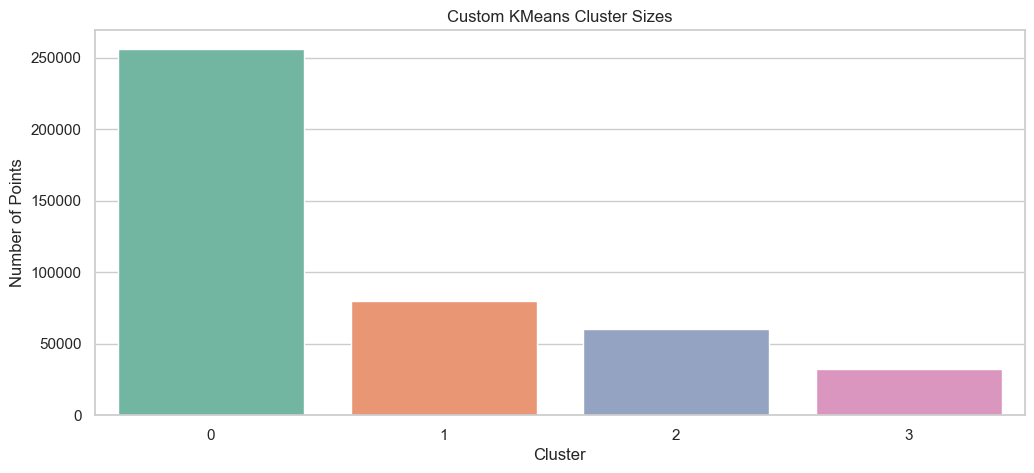

C:\Users\dell\AppData\Local\Temp\ipykernel_16736\1199437010.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cluster_sklearn', data=df_all, palette='Set2')


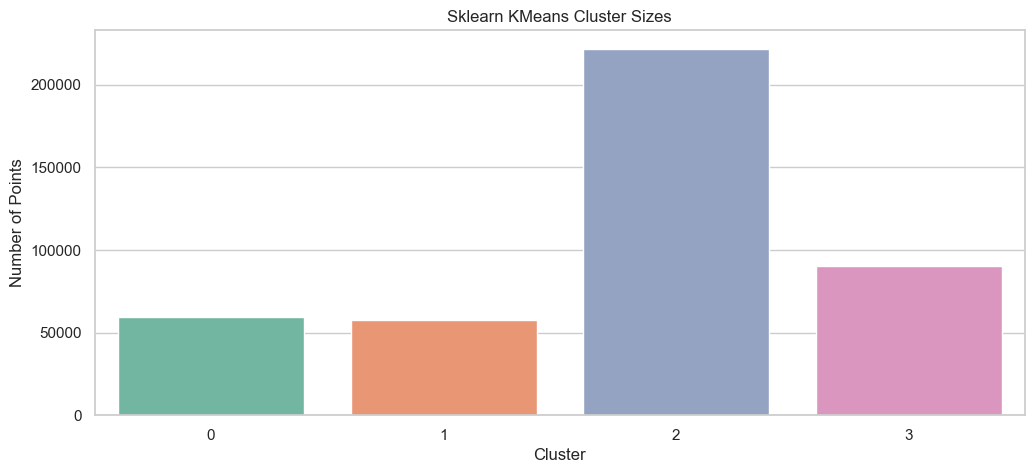

In [ ]:

plt.figure(figsize=(12,5))
sns.countplot(x='cluster_custom', data=df_all, palette='Set2')
plt.title("Custom KMeans Cluster Sizes")
plt.xlabel("Cluster")
plt.ylabel("Number of Points")
plt.show()

plt.figure(figsize=(12,5))
sns.countplot(x='cluster_sklearn', data=df_all, palette='Set2')
plt.title("Sklearn KMeans Cluster Sizes")
plt.xlabel("Cluster")
plt.ylabel("Number of Points")
plt.show()



C:\Users\dell\AppData\Local\Temp\ipykernel_16736\1042538298.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fire_custom.index, y=fire_custom.values, ax=axes[0], palette='Reds')
C:\Users\dell\AppData\Local\Temp\ipykernel_16736\1042538298.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fire_sklearn.index, y=fire_sklearn.values, ax=axes[1], palette='Reds')


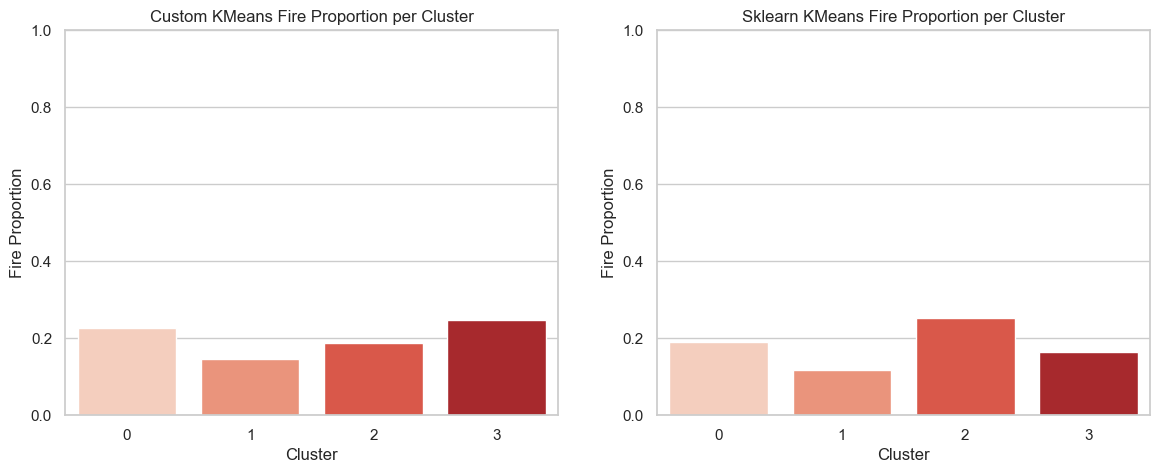

In [ ]:
fire_custom = df_all.groupby('cluster_custom')['fire'].mean()
fire_sklearn = df_all.groupby('cluster_sklearn')['fire'].mean()

fig, axes = plt.subplots(1,2, figsize=(14,5))
sns.barplot(x=fire_custom.index, y=fire_custom.values, ax=axes[0], palette='Reds')
axes[0].set_title("Custom KMeans Fire Proportion per Cluster")
axes[0].set_ylim(0,1)
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("Fire Proportion")

sns.barplot(x=fire_sklearn.index, y=fire_sklearn.values, ax=axes[1], palette='Reds')
axes[1].set_title("Sklearn KMeans Fire Proportion per Cluster")
axes[1].set_ylim(0,1)
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("Fire Proportion")

plt.show()


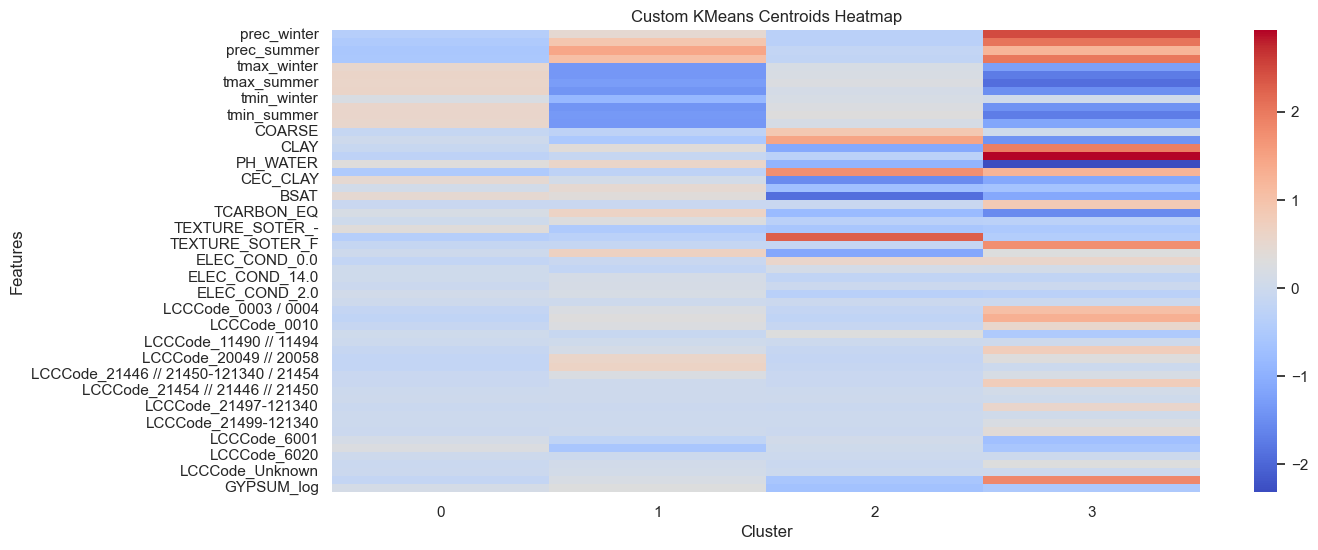

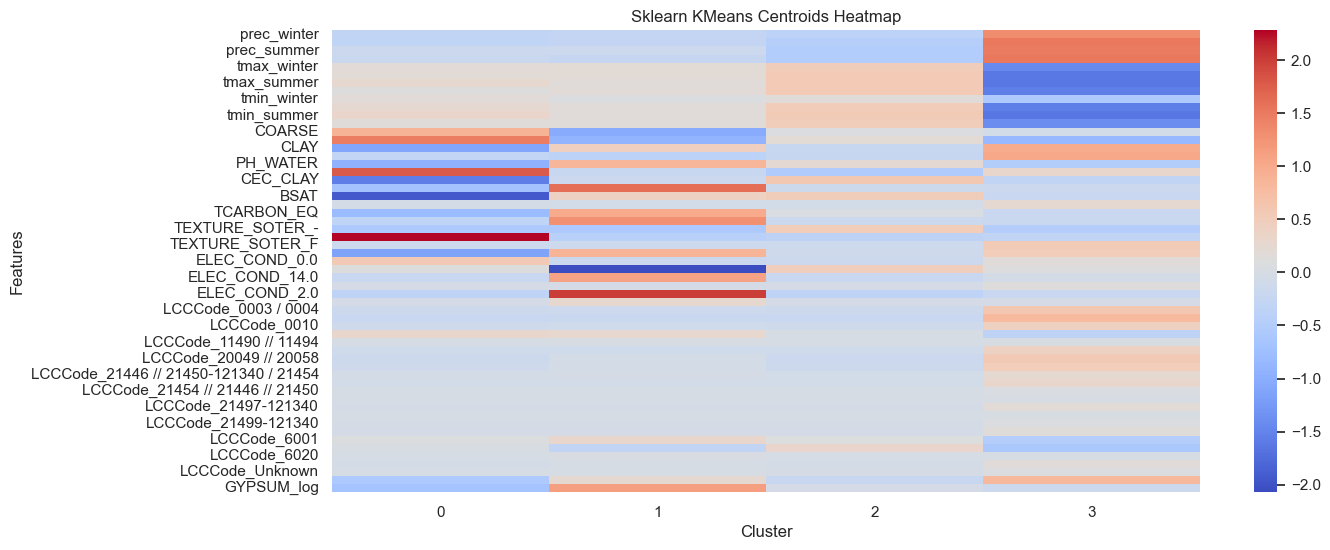

In [ ]:
# Custom centroids
centroids_custom_df = pd.DataFrame(centroids_custom, columns=numeric_cols)
centroids_custom_df['cluster'] = range(K)
centroids_custom_df.set_index('cluster', inplace=True)

# Sklearn centroids
centroids_sklearn_df = pd.DataFrame(kmeans.cluster_centers_, columns=numeric_cols)
centroids_sklearn_df['cluster'] = range(K)
centroids_sklearn_df.set_index('cluster', inplace=True)

# Plot heatmaps
plt.figure(figsize=(14,6))
sns.heatmap(centroids_custom_df.T, cmap='coolwarm', annot=False)
plt.title("Custom KMeans Centroids Heatmap")
plt.xlabel("Cluster")
plt.ylabel("Features")
plt.show()

plt.figure(figsize=(14,6))
sns.heatmap(centroids_sklearn_df.T, cmap='coolwarm', annot=False)
plt.title("Sklearn KMeans Centroids Heatmap")
plt.xlabel("Cluster")
plt.ylabel("Features")
plt.show()


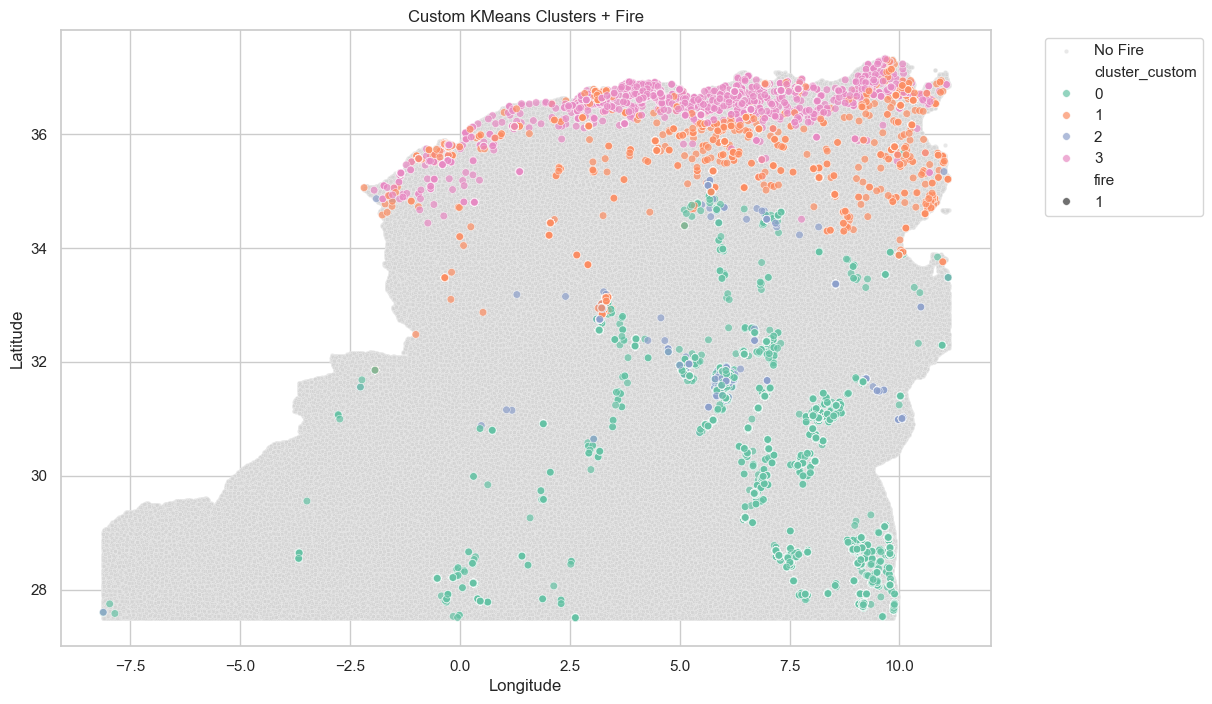

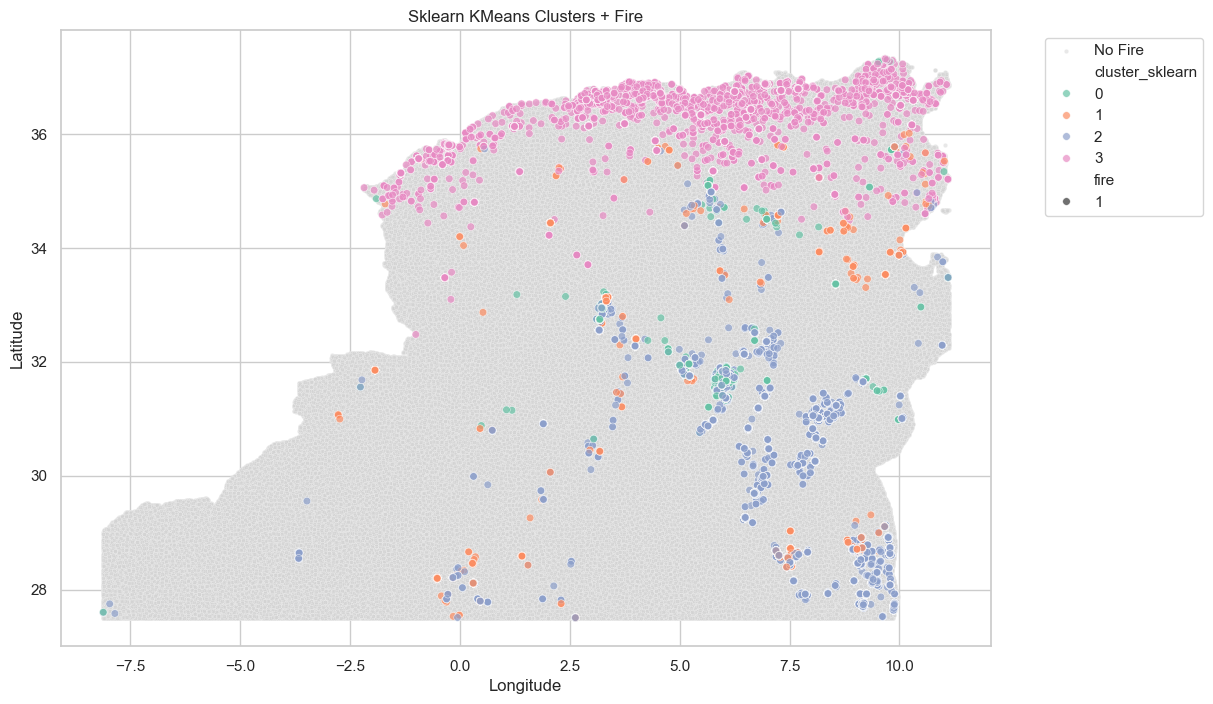

In [ ]:
# Function to plot clusters + fire
def plot_geo_clusters(df, cluster_col, title):
    plt.figure(figsize=(12,8))

    # Non-fire points
    sns.scatterplot(
        x='lon', y='lat',
        data=df[df['fire']==0],
        color='lightgray',
        s=10,
        alpha=0.5,
        label='No Fire'
    )

    # Fire points
    sns.scatterplot(
        x='lon', y='lat',
        hue=cluster_col,
        style='fire',
        data=df[df['fire']==1],
        palette='Set2',
        s=30,
        alpha=0.7,
        legend='full'
    )

    plt.title(title)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

# Custom
plot_geo_clusters(df_all, 'cluster_custom', "Custom KMeans Clusters + Fire")

# Sklearn
plot_geo_clusters(df_all, 'cluster_sklearn', "Sklearn KMeans Clusters + Fire")


C:\Users\dell\AppData\Local\Temp\ipykernel_16736\1830925318.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster_custom', y=feature, data=df_all, palette='Set3')


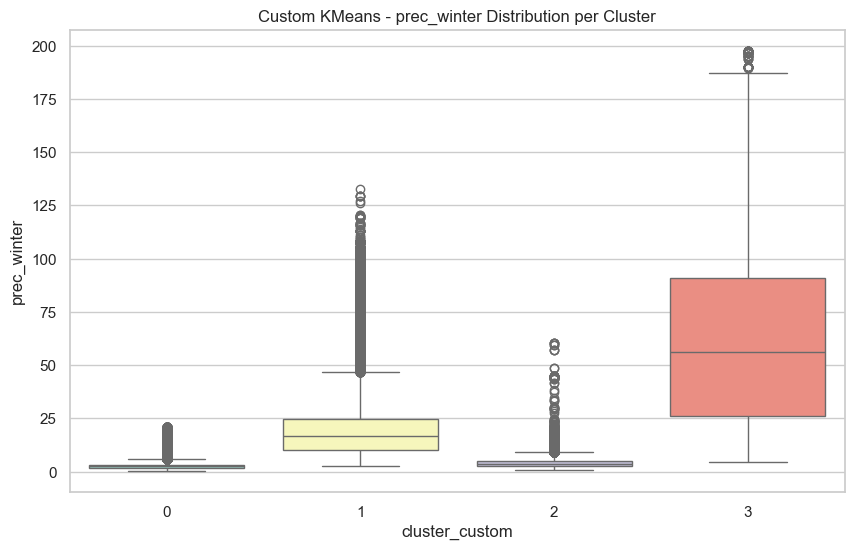

C:\Users\dell\AppData\Local\Temp\ipykernel_16736\1830925318.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster_custom', y=feature, data=df_all, palette='Set3')


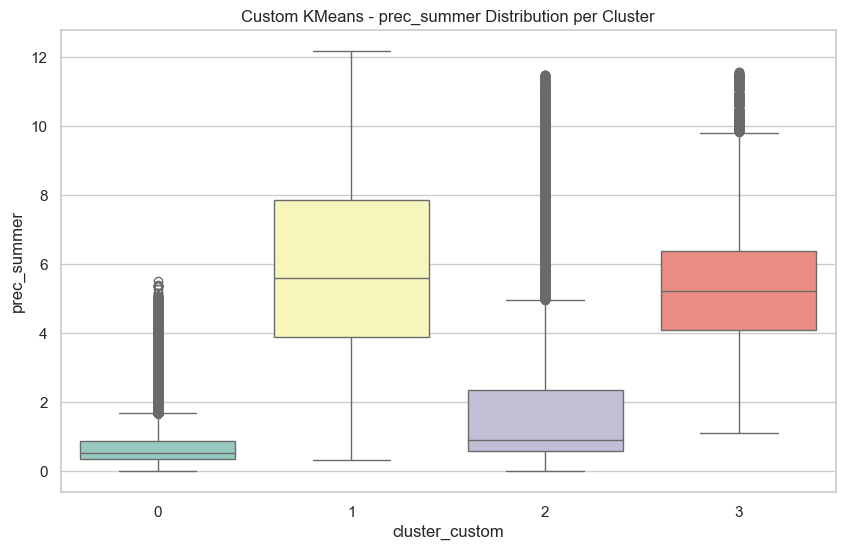

C:\Users\dell\AppData\Local\Temp\ipykernel_16736\1830925318.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster_custom', y=feature, data=df_all, palette='Set3')


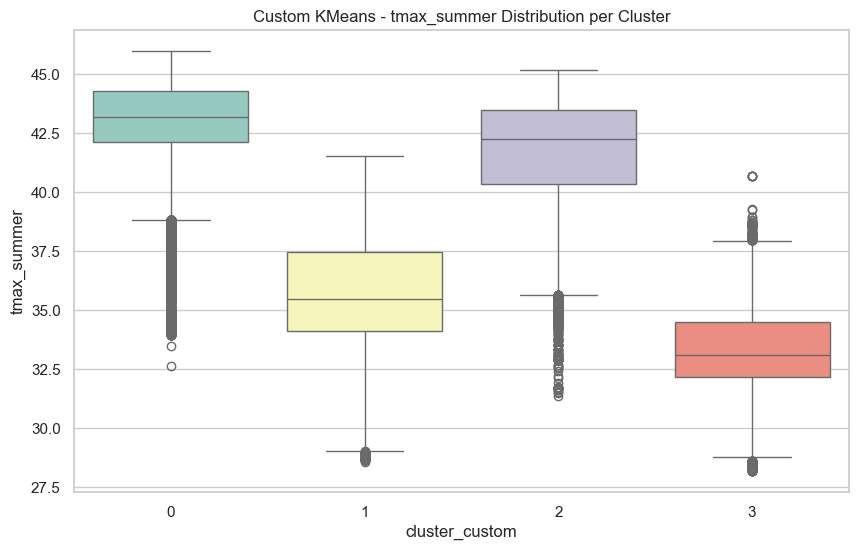

C:\Users\dell\AppData\Local\Temp\ipykernel_16736\1830925318.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster_custom', y=feature, data=df_all, palette='Set3')


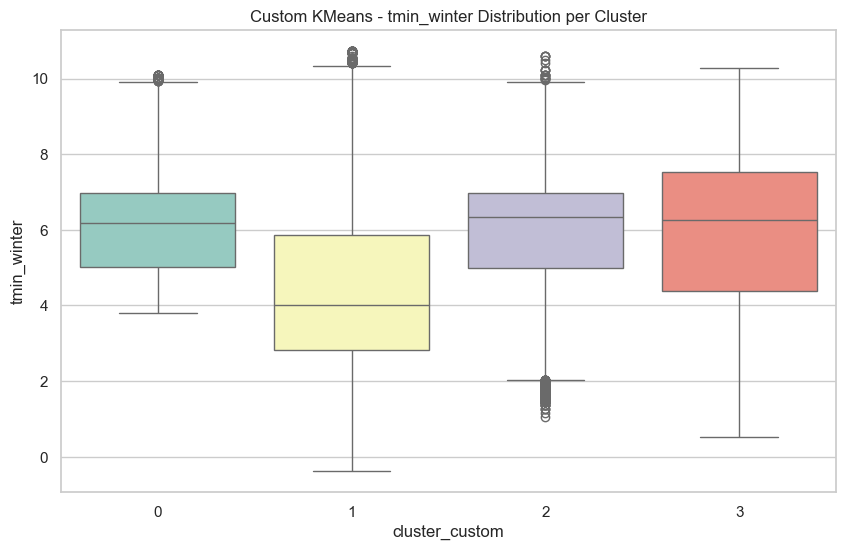

C:\Users\dell\AppData\Local\Temp\ipykernel_16736\1830925318.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster_custom', y=feature, data=df_all, palette='Set3')


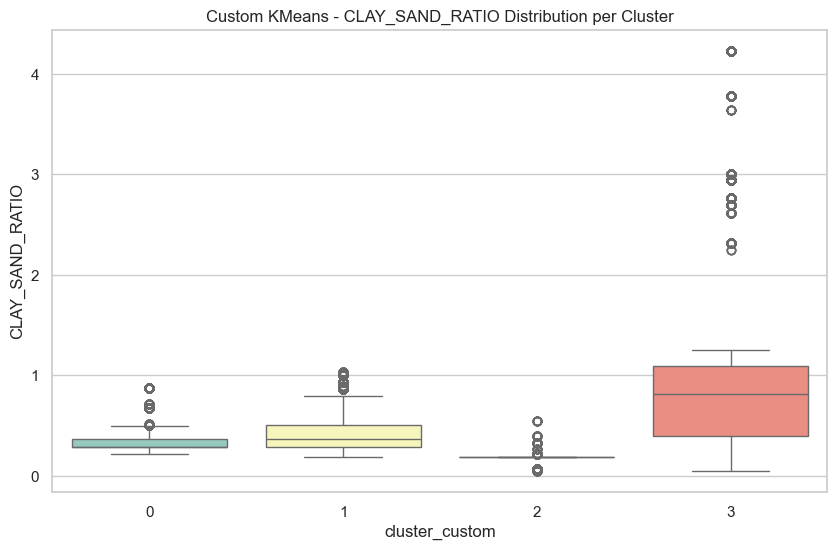

C:\Users\dell\AppData\Local\Temp\ipykernel_16736\1830925318.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster_sklearn', y=feature, data=df_all, palette='Set3')


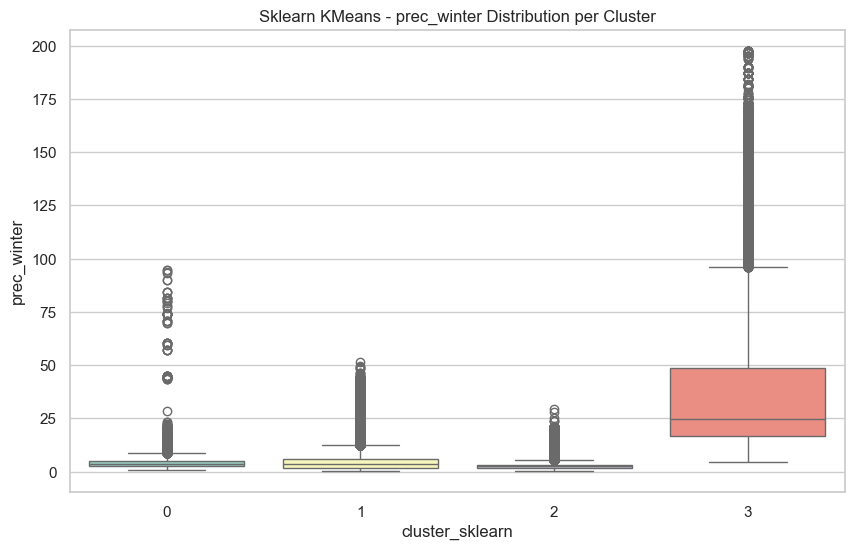

C:\Users\dell\AppData\Local\Temp\ipykernel_16736\1830925318.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster_sklearn', y=feature, data=df_all, palette='Set3')


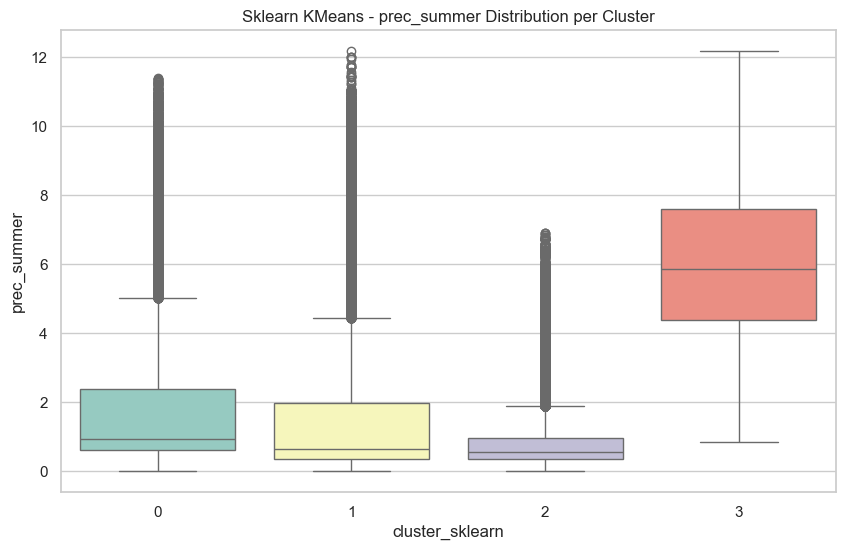

C:\Users\dell\AppData\Local\Temp\ipykernel_16736\1830925318.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster_sklearn', y=feature, data=df_all, palette='Set3')


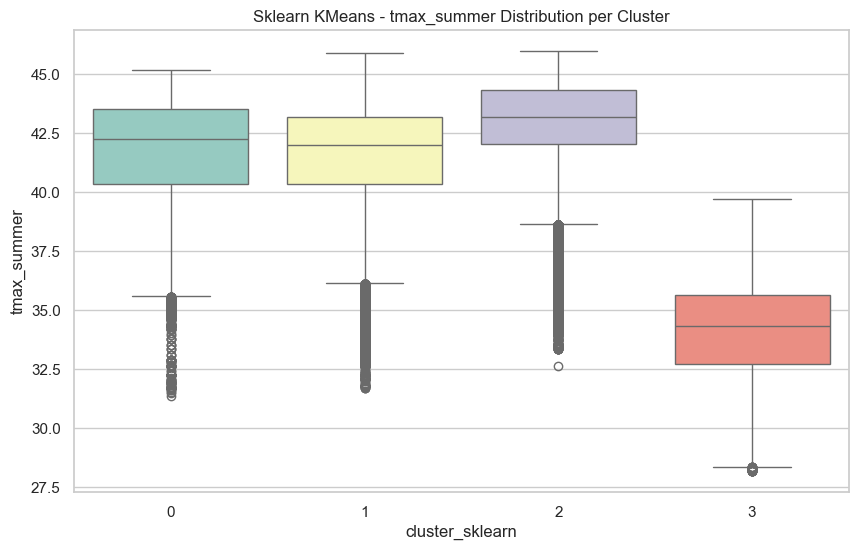

C:\Users\dell\AppData\Local\Temp\ipykernel_16736\1830925318.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster_sklearn', y=feature, data=df_all, palette='Set3')


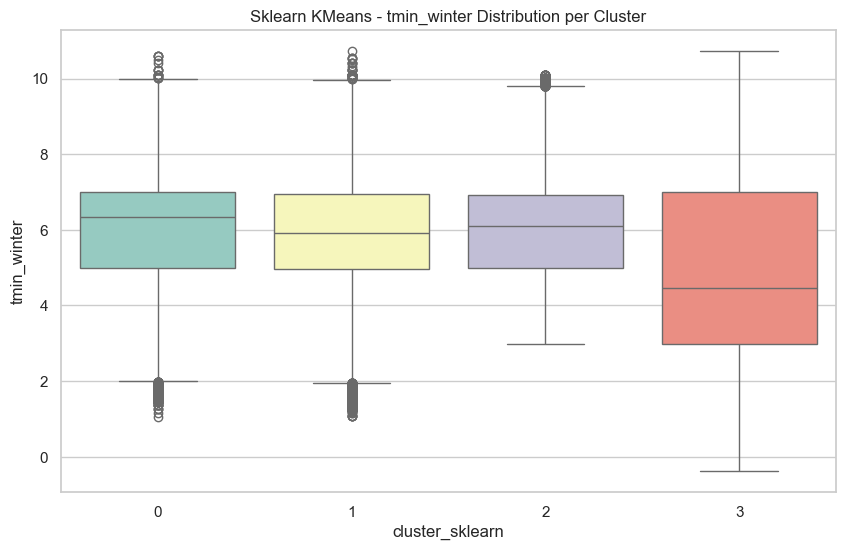

C:\Users\dell\AppData\Local\Temp\ipykernel_16736\1830925318.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster_sklearn', y=feature, data=df_all, palette='Set3')


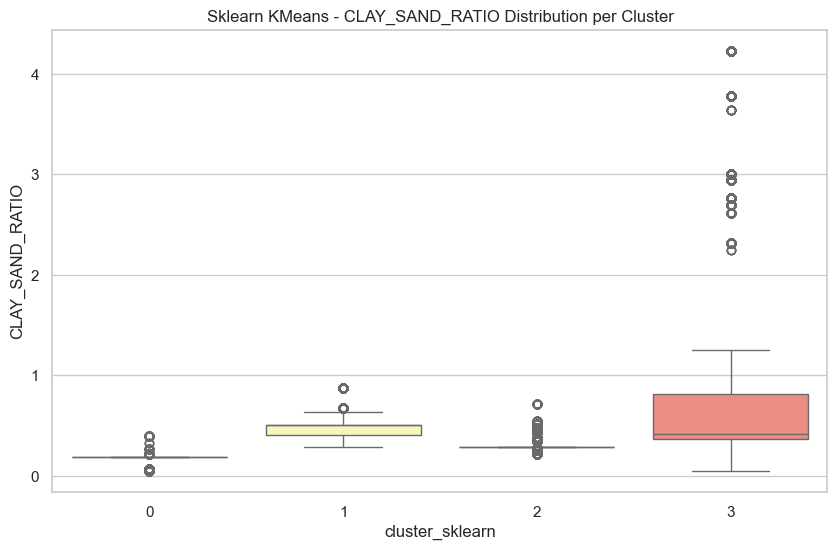

In [ ]:
key_features = ['prec_winter', 'prec_summer', 'tmax_summer', 'tmin_winter', 'CLAY_SAND_RATIO']

# Custom KMeans
for feature in key_features:
    plt.figure()
    sns.boxplot(x='cluster_custom', y=feature, data=df_all, palette='Set3')
    plt.title(f"Custom KMeans - {feature} Distribution per Cluster")
    plt.show()

# Sklearn KMeans
for feature in key_features:
    plt.figure()
    sns.boxplot(x='cluster_sklearn', y=feature, data=df_all, palette='Set3')
    plt.title(f"Sklearn KMeans - {feature} Distribution per Cluster")
    plt.show()


## dbscan

```The dataset contains 57 numeric features, many of which are correlated and high-dimensional. DBSCAN relies on distance between points to identify dense clusters, but in high dimensions, distances become less meaningful — this is known as the curse of dimensionality. To address this, Principal Component Analysis (PCA) is applied before DBSCAN to reduce the number of features while retaining most of the variance in the data. By projecting the data onto the first few principal components (e.g., 10–15), we preserve the main patterns and relationships among features, making the distance calculations more reliable for DBSCAN. This allows the algorithm to detect meaningful dense clusters and separate noise points effectively, without being overwhelmed by redundant or irrelevant dimensions.```

now tuning dbscan

In [ ]:
# eps: distance threshold
eps_candidates = np.arange(1.5, 1.0, 0.5)  # adjust depending on your k-distance plot

# min_samples: minimum points to form a dense cluster
min_samples_candidates = [30, 50, 100]  # small → many clusters, large → only dense clusters

# metric: distance metric
metrics = ['euclidean', 'manhattan']  # usually euclidean is fine


## Stratified sampling

In [ ]:
sample_size = 100000  # total points in sample

# Compute sample size per class to preserve fire ratio
fire_counts = df_all['fire'].value_counts(normalize=True)
n_fire = int(sample_size * fire_counts[1])
n_no_fire = sample_size - n_fire

# Sample points
sample_fire = df_all[df_all['fire'] == 1].sample(n=n_fire, random_state=42)
sample_no_fire = df_all[df_all['fire'] == 0].sample(n=n_no_fire, random_state=42)

# Combine
df_sample = pd.concat([sample_fire, sample_no_fire]).reset_index(drop=True)

# Exclude 'lat' and 'lon' from features
features_to_use = [col for col in numeric_cols if col not in ['lat', 'lon', 'fire']]
X_sample = df_sample[features_to_use]  # features for clustering


# Keep fire column for analysis
y_fire = df_sample['fire']  # to check cluster vs fire after DBSCAN



In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sample)

pca = PCA(n_components=7, random_state=42)
X_pca = pca.fit_transform(X_scaled)


parameter tuning

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import calinski_harabasz_score

# Example eps and min_samples grid
eps_values = [0.2, 0.4, 0.7]
min_samples_values = [5, 10, 20]

best_ch = -1
best_params = None

print("=== DBSCAN Hyperparameter Tuning ===")
for eps in eps_values:
    for min_samples in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1)
        labels = db.fit_predict(X_pca)

        # Count clusters and noise points
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_pct = np.sum(labels == -1) / len(labels) * 100

        # Only calculate CH score if we have at least 2 clusters
        if n_clusters > 1:
            ch = calinski_harabasz_score(X_pca, labels)
            print(f"eps={eps}, min_samples={min_samples} -> clusters={n_clusters}, noise={noise_pct:.1f}%, CH={ch:.1f}")

            if ch > best_ch:
                best_ch = ch
                best_params = (eps, min_samples, n_clusters, noise_pct)

print("\n=== Best DBSCAN Parameters ===")
print(f"eps={best_params[0]}, min_samples={best_params[1]}")
print(f"Clusters={best_params[2]}, Noise={best_params[3]:.1f}%, CH Score={best_ch:.1f}")


=== DBSCAN Hyperparameter Tuning ===
eps=0.2, min_samples=5 -> clusters=805, noise=8.9%, CH=584.8
eps=0.2, min_samples=10 -> clusters=390, noise=14.3%, CH=815.3
eps=0.2, min_samples=20 -> clusters=215, noise=20.9%, CH=999.8
eps=0.4, min_samples=5 -> clusters=470, noise=2.8%, CH=1689.7
eps=0.4, min_samples=10 -> clusters=319, noise=5.3%, CH=1866.6
eps=0.4, min_samples=20 -> clusters=228, noise=9.4%, CH=1845.5
eps=0.7, min_samples=5 -> clusters=261, noise=0.9%, CH=1961.6
eps=0.7, min_samples=10 -> clusters=189, noise=1.9%, CH=2438.3
eps=0.7, min_samples=20 -> clusters=138, noise=3.6%, CH=2957.3

=== Best DBSCAN Parameters ===
eps=0.7, min_samples=20
Clusters=138, Noise=3.6%, CH Score=2957.3


CH score is highest at eps=0.7, min_samples=20

running dbscan on parameters

In [ ]:
# ------------------------------
# 5. DBSCAN with tuned hyperparameters
# ------------------------------
eps_opt = 0.7
min_samples_opt = 20

db = DBSCAN(eps=eps_opt, min_samples=min_samples_opt, n_jobs=-1)
labels = db.fit_predict(X_pca)

df_sample['dbscan_cluster'] = labels

# Count clusters and noise
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
noise_pct = np.sum(labels==-1)/len(labels)*100

print(f"DBSCAN results: clusters={n_clusters}, noise={noise_pct:.2f}%")

DBSCAN results: clusters=138, noise=3.58%


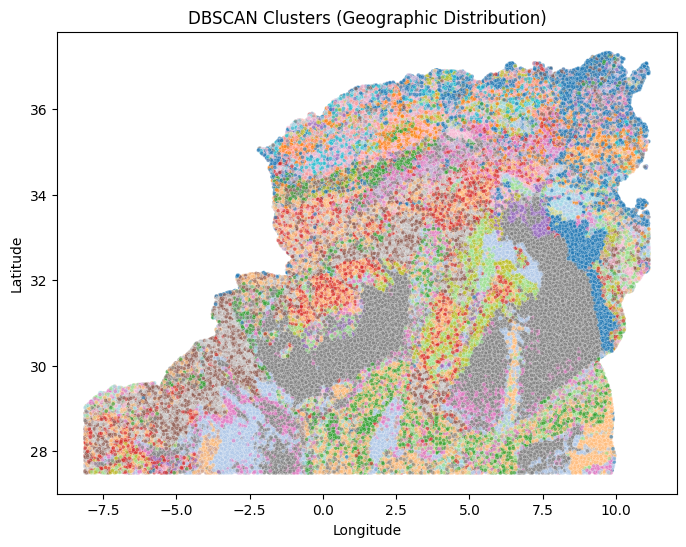

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='lon',
    y='lat',
    hue='dbscan_cluster',
    data=df_sample,
    palette='tab20',
    s=8,
    alpha=0.6,
    legend=False   # IMPORTANT: too many clusters
)

plt.title("DBSCAN Clusters (Geographic Distribution)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


Although DBSCAN clusters are not geographically contiguous, this is expected since latitude and longitude were excluded from the feature space. The algorithm therefore groups locations with similar environmental and climatic characteristics rather than spatial proximity, which is appropriate for fire-risk and environmental pattern analysis.

from scratch

In [ ]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
import time

class DBSCAN_Scratch:
    def __init__(self, eps=0.5, min_samples=5, algorithm="ball_tree"):
        self.eps = eps
        self.min_samples = min_samples
        self.algorithm = algorithm

    def fit(self, X):
        n = X.shape[0]
        self.labels_ = np.full(n, -1)   # -1 = unvisited, 0 = noise
        cluster_id = 0

        # Build spatial index
        self.nn = NearestNeighbors(
            radius=self.eps,
            algorithm=self.algorithm,
            n_jobs=-1
        )
        self.nn.fit(X)

        start_time = time.time()

        for i in range(n):
            if self.labels_[i] != -1:
                continue

            neighbors = self._region_query(X, i)

            if len(neighbors) < self.min_samples:
                self.labels_[i] = 0  # noise
                continue

            cluster_id += 1
            self._expand_cluster(X, i, neighbors, cluster_id)

            # Progress print every 100 points
            if i % 100 == 0:
                elapsed = time.time() - start_time
                pct = (i / n) * 100
                est_total = elapsed / (i + 1) * n
                remaining = est_total - elapsed
                print(
                    f"Processed {i}/{n} points ({pct:.1f}%), "
                    f"Clusters found: {cluster_id}, "
                    f"Elapsed: {elapsed/60:.1f} min, ETA: {remaining/60:.1f} min"
                )

        self.n_clusters_ = cluster_id
        return self

    def _region_query(self, X, i):
        return self.nn.radius_neighbors(
            X[i].reshape(1, -1),
            return_distance=False
        )[0]

    def _expand_cluster(self, X, i, neighbors, cluster_id):
        self.labels_[i] = cluster_id
        queue = list(neighbors)

        while queue:
            j = queue.pop(0)

            if self.labels_[j] == 0:
                self.labels_[j] = cluster_id

            if self.labels_[j] != -1:
                continue

            self.labels_[j] = cluster_id
            j_neighbors = self._region_query(X, j)

            if len(j_neighbors) >= self.min_samples:
                queue.extend(j_neighbors)

    def fit_predict(self, X):
        self.fit(X)
        return self.labels_




To ensure scalability on a dataset of 150k samples, DBSCAN was implemented using spatial indexing (Ball-Tree), enabling efficient ε-neighborhood queries. This avoids the quadratic complexity of naïve implementations while preserving the core DBSCAN principles.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
import time

# ---------------------------
# Define DBSCAN_Fast class (with noise)
# ---------------------------
class DBSCAN_Fast:
    def __init__(self, eps=0.5, min_samples=5, algorithm="ball_tree", n_jobs=-1):
        self.eps = eps
        self.min_samples = min_samples
        self.algorithm = algorithm
        self.n_jobs = n_jobs

    def fit(self, X):
        n = X.shape[0]
        self.labels_ = np.full(n, -1, dtype=int)  # -1 = noise/unvisited
        cluster_id = 0

        nn = NearestNeighbors(radius=self.eps, algorithm=self.algorithm, n_jobs=self.n_jobs)
        nn.fit(X)

        visited = np.zeros(n, dtype=bool)
        start_time = time.time()

        for i in range(n):
            if visited[i]:
                continue

            visited[i] = True
            neighbors = nn.radius_neighbors(X[i].reshape(1, -1), return_distance=False)[0]

            if len(neighbors) < self.min_samples:
                # Noise stays as -1
                continue

            # Start new cluster
            cluster_queue = neighbors[neighbors != i]  # exclude self
            self.labels_[i] = cluster_id

            while len(cluster_queue) > 0:
                j = cluster_queue[0]
                cluster_queue = cluster_queue[1:]

                if not visited[j]:
                    visited[j] = True
                    j_neighbors = nn.radius_neighbors(X[j].reshape(1, -1), return_distance=False)[0]

                    if len(j_neighbors) >= self.min_samples:
                        # Add only unvisited neighbors
                        cluster_queue = np.concatenate([cluster_queue, j_neighbors[~visited[j_neighbors]]])

                if self.labels_[j] == -1:  # assign cluster if previously noise
                    self.labels_[j] = cluster_id

            cluster_id += 1

            # Optional progress
            if i % 10000 == 0 and i != 0:
                elapsed = time.time() - start_time
                pct = (i / n) * 100
                est_total = elapsed / (i + 1) * n
                remaining = est_total - elapsed
                print(f"Processed {i}/{n} ({pct:.1f}%), clusters={cluster_id}, ETA={remaining/60:.1f} min")

        self.n_clusters_ = cluster_id
        return self

    def fit_predict(self, X):
        self.fit(X)
        return self.labels_

# ---------------------------
# Features for clustering
# ---------------------------
features_for_clustering = [
    'prec_winter','prec_spring','prec_summer','prec_fall',
    'tmax_winter','tmax_spring','tmax_summer','tmax_fall',
    'tmin_winter','tmin_spring','tmin_summer','tmin_fall',
    'elevation','COARSE','SAND','CLAY','ORG_CARBON','PH_WATER','CN_RATIO',
    'CEC_CLAY','CEC_EFF','BSAT','ALUM_SAT','TCARBON_EQ','GYPSUM',
    'CLAY_SAND_RATIO','GYPSUM_log'
]

# ---------------------------
# Prepare X (keep df_sample intact)
# ---------------------------
X = df_sample[features_for_clustering].values.astype(np.float32)

# ---------------------------
# Standardize
# ---------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ---------------------------
# Optional: PCA for speed
# ---------------------------
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)

# ---------------------------
# Run DBSCAN
# ---------------------------
dbscan = DBSCAN_Fast(eps=0.7, min_samples=20, n_jobs=-1)
labels = dbscan.fit_predict(X_pca)

df_sample['dbscanscratch_cluster'] = labels

# ---------------------------
# Check results
# ---------------------------
print(df_sample[['lat','lon','fire','dbscanscratch_cluster']].head())
print("Number of clusters found (excluding noise):", len(np.unique(labels[labels != -1])))
print("Number of noise points:", np.sum(labels == -1))



KeyboardInterrupt: 

```took too long + RAM```

## Clara

In [3]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

from pyclustering.cluster.kmedoids import kmedoids
from pyclustering.utils.metric import distance_metric, type_metric

import random



In [6]:
# Conversion DataFrame → NumPy
X = df_encoded.values

# Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Shape des données :", X_scaled.shape)


Shape des données : (428959, 58)


In [7]:
def clara_heuristic_params(X):
    """
    Une heuristique pour les paramètres CLARA
    en fonction de la taille (N) et de la dimension (d)
    """
    N, d = X.shape

    # Heuristique pour k
    k_center = int((N / 2) ** 0.5)
    k_values = list(range(max(2, k_center - 2), k_center + 3))

    # Heuristique pour sample_size
    if N < 10000:
        sample_size = int(0.1 * N)
    elif N < 100000:
        sample_size = 1000
    else:
        sample_size = 2000

    # Heuristique pour samples
    if d < 10:
        samples = 5
    else:
        samples = 10

    return k_values, [sample_size], [samples]


In [8]:
def run_clara(X, k, sample_size=1000, n_samples=5):
    """
    Implémentation de CLARA via k-medoids sur plusieurs échantillons.
    """
    N = len(X)
    best_sil = -1
    best_clusters = None
    best_medoids = None
    metric = distance_metric(type_metric.EUCLIDEAN)

    for s in range(n_samples):
        # Tirage d'un échantillon
        if sample_size < N:
            indices = np.random.choice(N, sample_size, replace=False)
            sample = X[indices]
        else:
            sample = X

        # Initialisation aléatoire des medoids
        initial_medoids = random.sample(range(len(sample)), k)

        # K-medoids
        km = kmedoids(sample, initial_medoids, metric=metric)
        km.process()
        clusters = km.get_clusters()
        medoids = km.get_medoids()

        # Construction des labels sur tout le dataset (approximation)
        labels = np.zeros(N, dtype=int)
        for cid, medoid_idx in enumerate(medoids):
            distances = np.linalg.norm(X - sample[medoid_idx], axis=1)
            labels[np.argsort(distances)[:len(sample)//k]] = cid

        # Évaluation silhouette sur l’échantillon
        try:
            sil = silhouette_score(sample, np.array([labels[i] for i in range(len(sample))]))
            if sil > best_sil:
                best_sil = sil
                best_clusters = clusters
                best_medoids = medoids
        except:
            continue

    return best_clusters, best_medoids


### Fine tuning de CLARA

In [9]:
k_values, sample_sizes, n_samples_list = clara_heuristic_params(X_scaled)

print("k testés :", k_values)
print("sample_size :", sample_sizes)
print("samples :", n_samples_list)


k testés : [461, 462, 463, 464, 465]
sample_size : [2000]
samples : [10]


In [10]:
from tqdm import tqdm


## GRAPHE CLARA

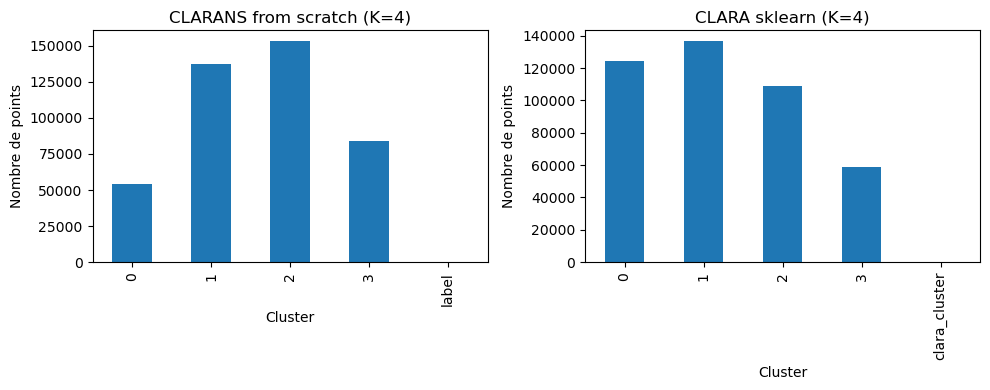

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ===============================
# Chargement des fichiers
# ===============================
path_clarans = "clarans_labels_k4.csv"
path_sklearn = "labels_clara_k4.csv"

labels_clarans = pd.read_csv(path_clarans, header=None).iloc[:, 0]
labels_sklearn = pd.read_csv(path_sklearn, header=None).iloc[:, 0]

# ===============================
# Distribution des clusters
# ===============================
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
labels_clarans.value_counts().sort_index().plot(
    kind="bar",
    title="CLARANS from scratch (K=4)",
    xlabel="Cluster",
    ylabel="Nombre de points"
)

plt.subplot(1, 2, 2)
labels_sklearn.value_counts().sort_index().plot(
    kind="bar",
    title="CLARA sklearn (K=4)",
    xlabel="Cluster",
    ylabel="Nombre de points"
)

plt.tight_layout()
plt.show()


     lat   lon  clarans_cluster  clara_cluster
0  30.29 -1.32                1              0
1  30.08 -1.22                1              0
2  32.61  1.10                2              2
3  33.31  0.74                3              2
4  27.88 -6.98                0              3


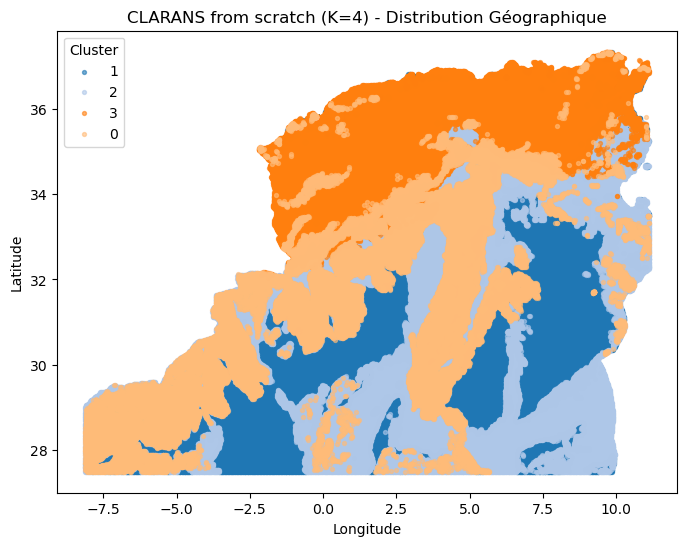

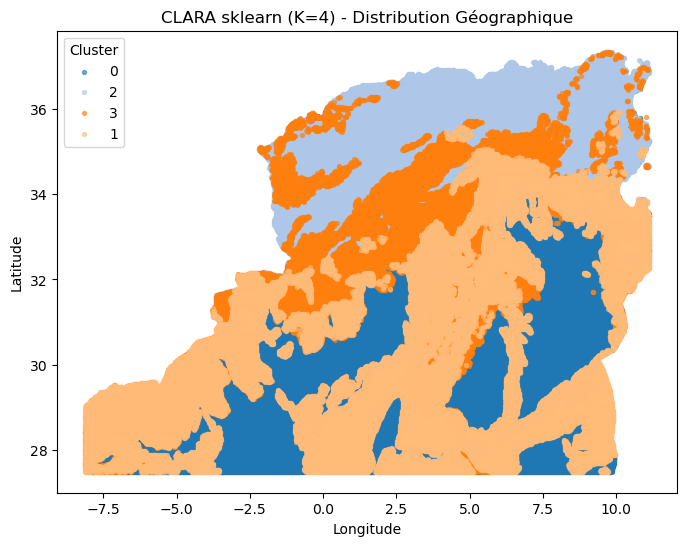

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import numpy as np

# ===============================
# 1. Chargement des labels CLARANS et CLARA (ignorer la première ligne)
# ===============================
path_clarans = r"D:\D\DATAMINING\output\clarans_labels_k4.csv"
path_sklearn = r"D:\D\DATAMINING\output\labels_clara_k4.csv"

# La première ligne est le nom de la colonne → header=0
labels_clarans = pd.read_csv(path_clarans, header=0).iloc[:, 0]
labels_sklearn = pd.read_csv(path_sklearn, header=0).iloc[:, 0]

# ===============================
# 2. Chargement du DataFrame df_all
# ===============================
all_path = r"data/processed/df_all.pkl"
with open(all_path, "rb") as f:
    df_all = pickle.load(f)

# ===============================
# 3. Vérification de la longueur
# ===============================
min_len = min(len(df_all), len(labels_clarans), len(labels_sklearn))
df_all = df_all.iloc[:min_len]
labels_clarans = labels_clarans.iloc[:min_len]
labels_sklearn = labels_sklearn.iloc[:min_len]

# ===============================
# 4. Ajouter les labels comme colonnes
# ===============================
df_all['clarans_cluster'] = labels_clarans.values
df_all['clara_cluster'] = labels_sklearn.values

# ===============================
# 5. Vérification rapide
# ===============================
print(df_all[['lat','lon','clarans_cluster','clara_cluster']].head())

# ===============================
# 6. Fonction pour visualiser les clusters géographiques
# ===============================
def plot_clusters_geo(df, cluster_col, title, s=8):
    plt.figure(figsize=(8,6))
    clusters = df[cluster_col].unique()
    colors = plt.cm.tab20.colors  # palette avec 20 couleurs

    for i, cluster in enumerate(clusters):
        subset = df[df[cluster_col] == cluster]
        plt.scatter(subset['lon'], subset['lat'],
                    s=s, alpha=0.6,
                    color=colors[i % len(colors)],
                    label=str(cluster))
    
    plt.title(title)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.legend(title="Cluster")
    plt.show()

# ===============================
# 7. Projection sur la carte
# ===============================
plot_clusters_geo(df_all, 'clarans_cluster', "CLARANS from scratch (K=4) - Distribution Géographique")
plot_clusters_geo(df_all, 'clara_cluster', "CLARA sklearn (K=4) - Distribution Géographique")
